# **Pontificia Universidad Javeriana**
# **Proyecto Técnicas de Aprendizaje de Máquina**
**Hecho por:**

Juan Diego Reyes

Mariana Díaz

Isaac Janica


<img src="http://t3.gstatic.com/licensed-image?q=tbn:ANd9GcQFZMv-iyoK_oIBwKhxFTS4i5Byb0esE5g_0xVan2ydimeoZ3_pO1KLJDOIqsEH9oVpWGNIGBvRPW_z_ibDE48" alt="Penguins" width="600"/>

*Abstract:*

---

### **Reporte: Análisis del Conjunto de Datos de los Pingüinos de Palmer**

#### **Introducción**

La segmentación de clientes es una técnica que permite dividir un conjunto de clientes en grupos
o segmentos con caracterı́sticas similares. Esto facilita la creación de estrategias personalizadas, como
campañas de marketing o mejoras en productos, al entender mejor el comportamiento y las necesidades
de cada grupo. A través de métodos de análisis de datos como K-Means, es posible identificar patrones
en los datos sin etiquetas, permitiendo a las empresas tomar decisiones más informadas y efectivas.

---

#### **Estructura y Variables**

El conjunto de datos está compuesto por una mezcla de variables numéricas y categóricas que ofrecen una visión detallada de cada pingüino. Las variables clave son:

| **Variable**                      | **Tipo**                 | **Descripción**                                                                 |
|----------------------------------|--------------------------|----------------------------------------------------------------------------------|
| edad                             | Numérica (entera)        | Edad del cliente en años.                                                       |
| ingresos_anuales                 | Numérica (continua)      | Ingreso anual estimado del cliente (USD).                                       |
| cantidad_compras                 | Numérica (entera)        | Número total de compras realizadas.                                             |
| valor_promedio_compra           | Numérica (continua)      | Valor promedio en dólares por compra.                                           |
| frecuencia_compras_mensual      | Numérica (continua)      | Promedio de compras realizadas por mes.                                         |
| dispositivo_utilizado           | Categórica               | Dispositivo más usado (móvil, PC, tablet).                                      |
| fuente_trafico                  | Categórica               | Canal de adquisición (redes sociales, búsqueda, email).                         |
| dias_desde_ultima_compra        | Numérica (entera)        | Días transcurridos desde la última compra.                                      |
| valor_total_gastado             | Numérica (continua)      | Total de dinero gastado en todas las compras (USD).                             |
| satisfaccion_cliente            | Numérica (continua)      | Nivel de satisfacción (escala de 1 a 5).                                         |
| metodo_pago                     | Categórica               | Método de pago más frecuente (tarjeta, PayPal, transferencia).                  |
| participacion_programa_lealtad  | Binaria (0/1)            | Indica si participa en el programa de lealtad.                                  |
| productos_adquiridos            | Categórica               | Categoría principal de productos adquiridos.                                    |



Vale la pena aclarar que nuestra variable objetivo para esta clasificación va a ser la especie del pingüino.
Parte de este notebook está basado en: https://www.kaggle.com/code/irenehavsa/eda-palmer-archipelago-penguins


# 1. **Carga de Datos**




In [ ]:
from google.colab import drive


drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

clientes = pd.read_csv('/content/drive/MyDrive/dataset_proyecto_2.csv')
clientes.head()


,edad,ingresos_anuales,cantidad_compras,valor_promedio_compra,frecuencia_compras_mensual,dispositivo_utilizado,fuente_trafico,dias_desde_ultima_compra,valor_total_gastado,satisfaccion_cliente,metodo_pago,participacion_programa_lealtad,productos_adquiridos
0,28,90455,4,135,0.921436,tablet,redes sociales,230,3369,2.929789,tarjeta crédito,0,computadoras
1,35,55842,19,367,5.321630,móvil,búsqueda orgánica,17,8276,3.446550,tarjeta crédito,1,accesorios
2,30,23268,39,257,9.021315,móvil,búsqueda orgánica,13,2216,4.034947,tarjeta crédito,0,accesorios
3,35,60841,8,862,2.865878,móvil,búsqueda orgánica,72,8003,3.466717,paypal,0,electrodomésticos
4,25,100485,19,444,7.365862,móvil,redes sociales,57,8550,4.310355,paypal,1,móviles


#2. **Análisis Exploratorio**

In [ ]:
clientes.isnull().sum()

,0
edad,0
ingresos_anuales,0
cantidad_compras,0
valor_promedio_compra,0
frecuencia_compras_mensual,0
dispositivo_utilizado,0
fuente_trafico,0
dias_desde_ultima_compra,0
valor_total_gastado,0
satisfaccion_cliente,0


Como se puede observar en la tabla, no se cuentan con nulos explícitos dentro del dataset.

In [ ]:
clientes.dtypes

,0
edad,int64
ingresos_anuales,int64
cantidad_compras,int64
valor_promedio_compra,int64
frecuencia_compras_mensual,float64
dispositivo_utilizado,object
fuente_trafico,object
dias_desde_ultima_compra,int64
valor_total_gastado,int64
satisfaccion_cliente,float64


In [ ]:
len(clientes)

1833331

In [ ]:
clientes.describe()

,edad,ingresos_anuales,cantidad_compras,valor_promedio_compra,frecuencia_compras_mensual,dias_desde_ultima_compra,valor_total_gastado,satisfaccion_cliente,participacion_programa_lealtad
count,1.833331e+06,1.833331e+06,1.833331e+06,1.833331e+06,1.833331e+06,1.833331e+06,1.833331e+06,1.833331e+06,1.833331e+06
mean,3.877552e+01,7.614756e+04,1.408932e+01,4.301820e+02,5.487638e+00,9.651723e+01,7.045614e+03,3.761349e+00,4.636860e-01
std,1.358327e+01,4.419407e+04,1.182157e+01,3.086627e+02,4.209958e+00,1.065618e+02,6.204356e+03,7.281546e-01,4.986797e-01
min,1.800000e+01,1.000000e+04,1.000000e+00,5.000000e+01,2.000125e-01,1.000000e+00,1.000000e+03,2.000002e+00,0.000000e+00
25%,2.900000e+01,4.131500e+04,4.000000e+00,1.960000e+02,1.235148e+00,1.200000e+01,2.944000e+03,3.220253e+00,0.000000e+00
50%,3.500000e+01,6.750700e+04,9.000000e+00,3.610000e+02,5.749663e+00,4.500000e+01,4.606000e+03,3.823675e+00,0.000000e+00
75%,4.700000e+01,1.078480e+05,2.100000e+01,5.400000e+02,9.280341e+00,1.640000e+02,8.770000e+03,4.348068e+00,1.000000e+00
max,6.900000e+01,1.999990e+05,4.900000e+01,1.499000e+03,1.499999e+01,3.640000e+02,2.999900e+04,5.000000e+00,1.000000e+00


In [ ]:
numeric_clientes = clientes.select_dtypes(include=['number'])
numeric_clientes.median()

,0
edad,35.000000
ingresos_anuales,67507.000000
cantidad_compras,9.000000
valor_promedio_compra,361.000000
frecuencia_compras_mensual,5.749663
dias_desde_ultima_compra,45.000000
valor_total_gastado,4606.000000
satisfaccion_cliente,3.823675
participacion_programa_lealtad,0.000000


Si bien en la primera tabla se obtienen estadísticas relevantes como la media y la desviación estándar, se sabe que estas medidas no son del todo robustas es por esto que se recurre a la mediana la cuál es una estadística más robusta y vemos que:
1. La edad de los clientes está alrededor de los 35 años.
2. Los ingresos anuales se encuentran alrededor de los 67507 USD.
3. El valor promedio por compra está alrededor de los 361 USD.
4. La frecuencia de compras mensual está alrededor de los 5.74 veces sin embargo esto puede ser un poco inverosímil con el hecho de que los días transcurridos desde la última compra se encuentran alrededor de los 45 días.
5. El valor total gastado está alrededor de los 4606 USD.
6. La satisfacción del cliente se encuentra alrededor de una punutación de 3.82, no se puede determinar si esta satisfación es alta o baja dado que esto depende del promedio de la industria.

Si bien estos valores nos pueden dar una ídea de como se distribuyen estos datos, se van a hacer gráficos para poder entender a mayor profundidad los datos.

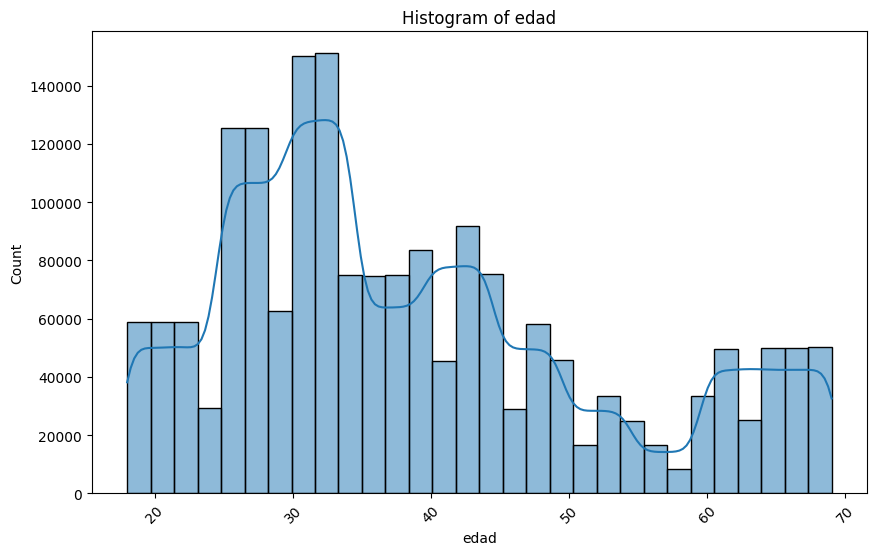

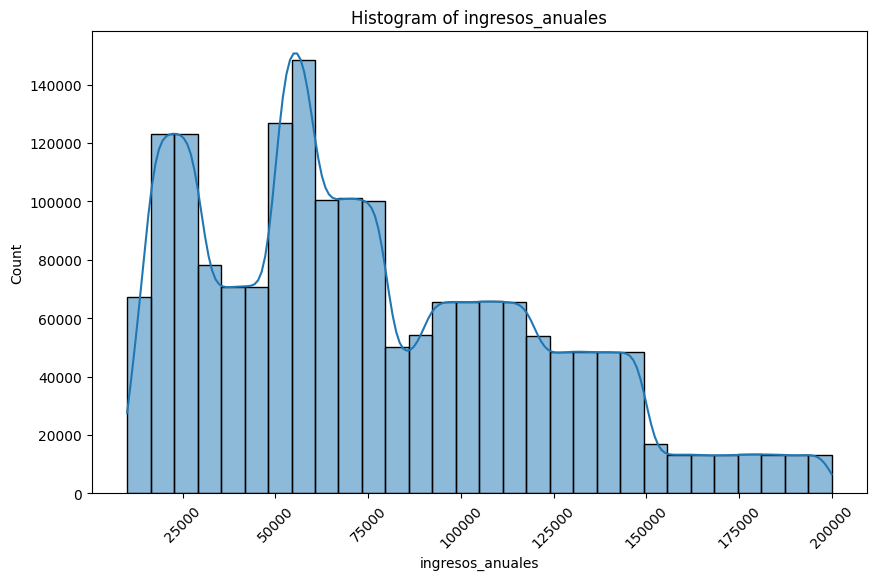

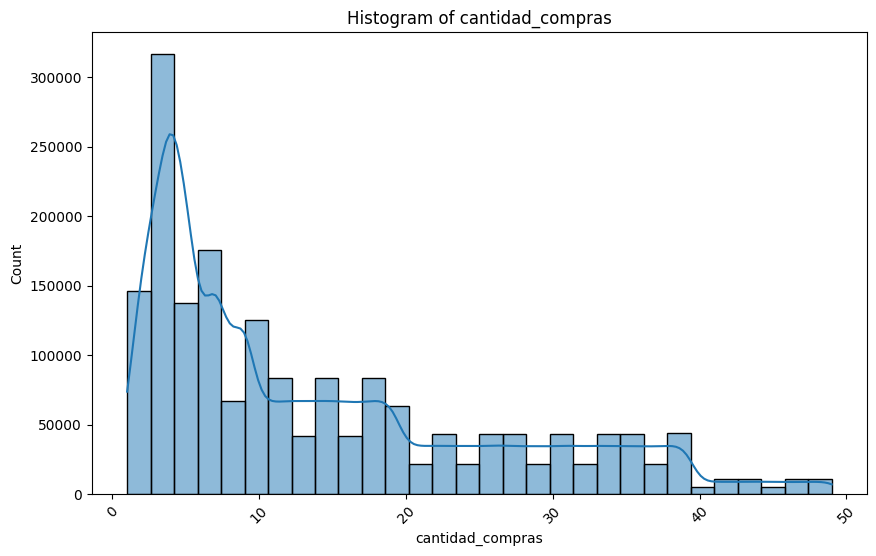

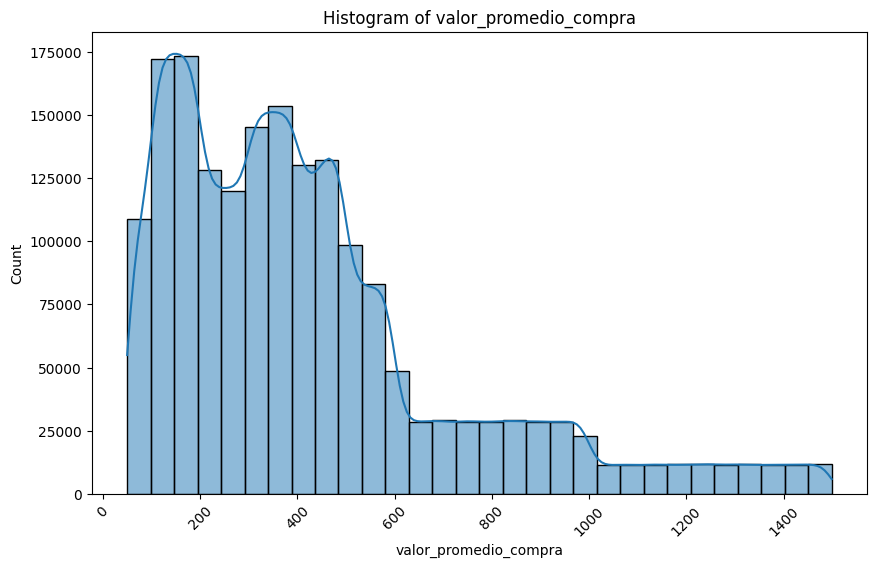

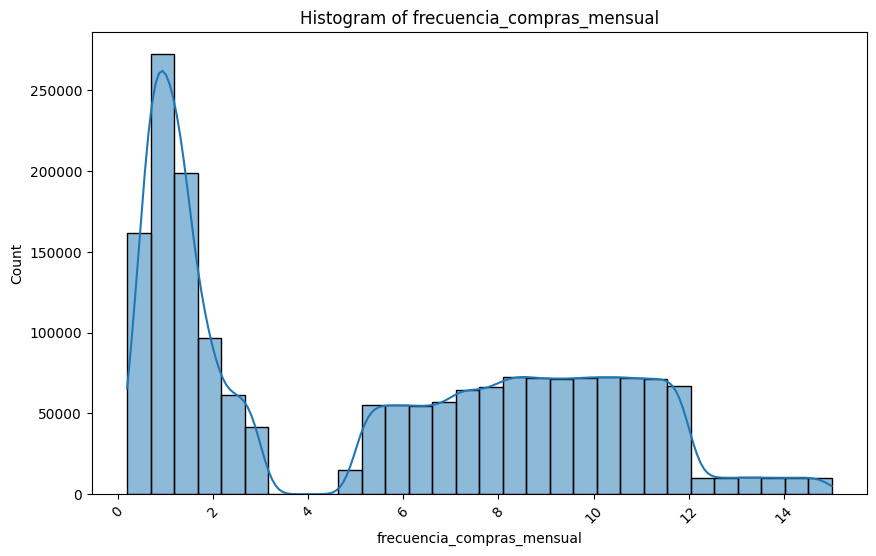

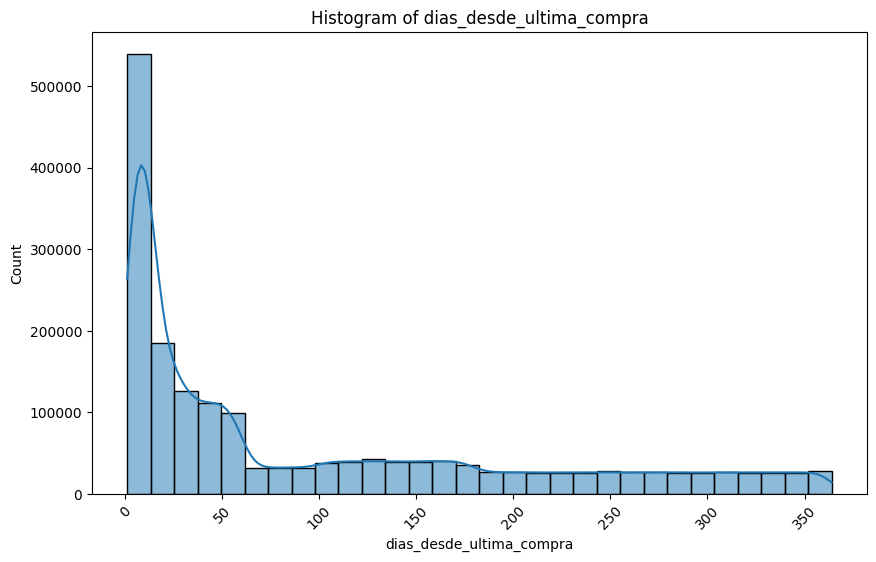

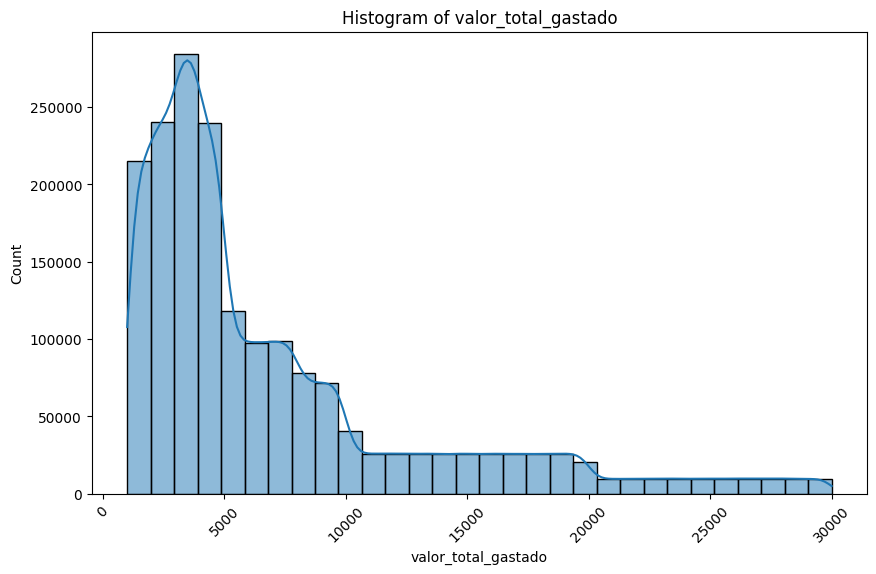

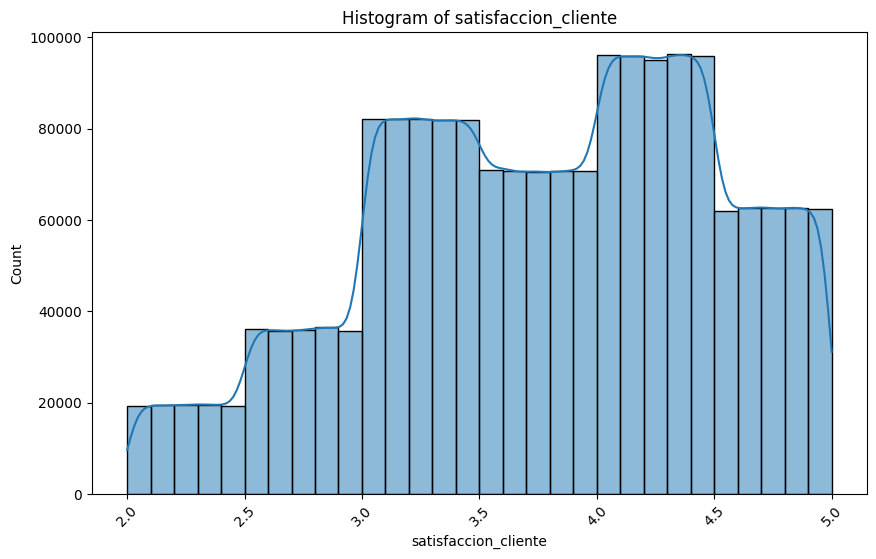

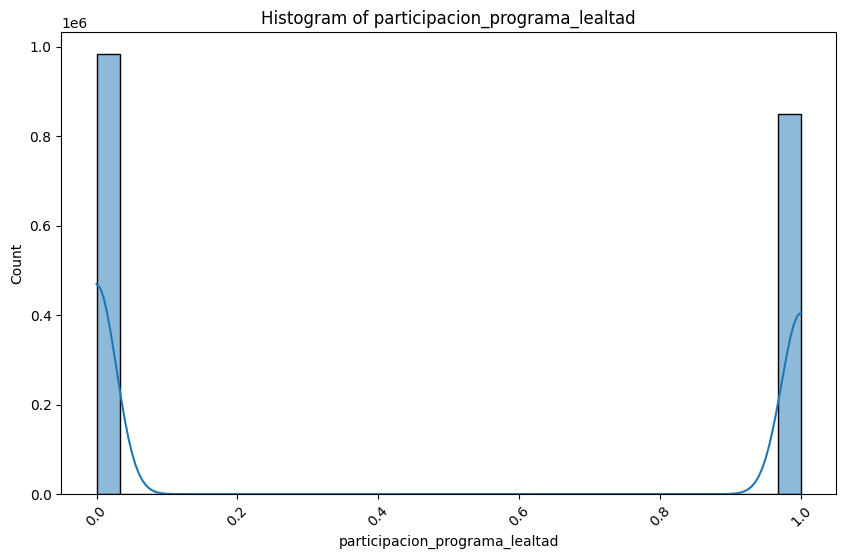

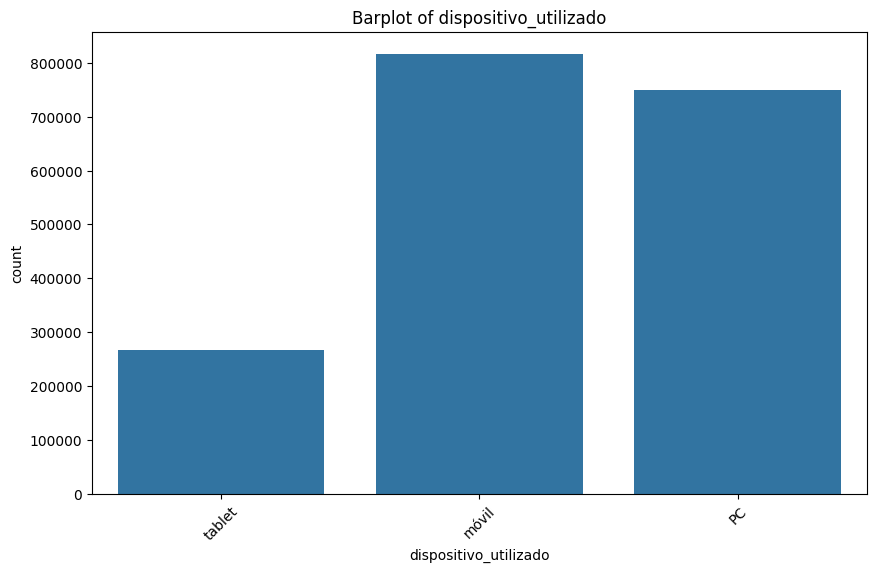

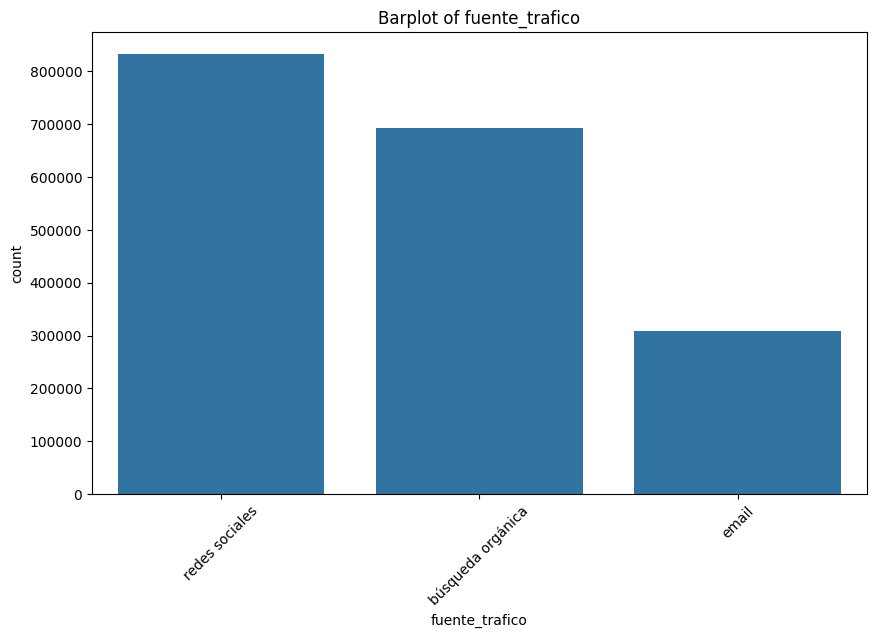

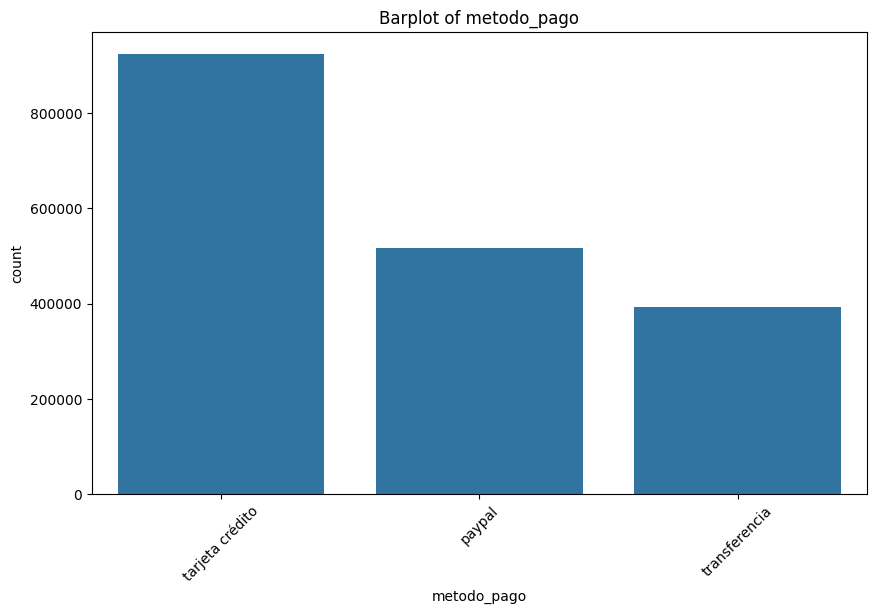

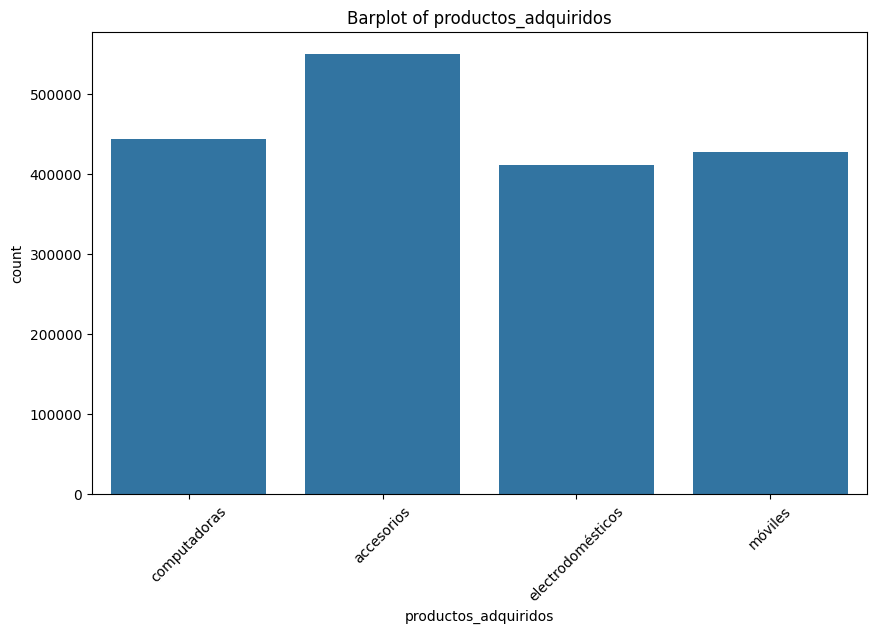

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

categorical_clientes = clientes.select_dtypes(exclude=['number'])

def plot_distribution(df):
    for column in df.columns:
        plt.figure(figsize=(10, 6))

        if df[column].dtype in ['int64', 'float64']:
            sns.histplot(df[column], kde=True, bins=30)
            plt.title(f'Histogram of {column}')

        else:
            sns.countplot(x=df[column])
            plt.title(f'Barplot of {column}')

        plt.xticks(rotation=45)
        plt.show()

plot_distribution(numeric_clientes)
plot_distribution(categorical_clientes)

De las gráficas de las variables numéricas se puede concluir lo siguiente:
1. Fue acertado utilizar la mediana como medida central dado que de las variables continuas ninguna es normal y los valores no se acumulan alrededor de este valor.
2. Las variables de la edad, ingresos anuales, cantidad de compras, valor promedio de compra, frecuencia de compras mensuales, días desde la última compra y valor total castado tienden a distribuirse hacia el lado izquierdo.
3. La satisfacción del cliente tiene una mayor tendencia hacia la derecha, esto puede ser positivo dado que significa que los clientes están más satisfechos que insatisfechos.
4. En la participaciíon en el programa de lealtad hay una leve cantidad de clientes que no participacipan en este programa más, que los que si.

De las gráficas de las variables categóricas se puede concluir que:
1. Los dos dispositivos más usados para las compras son el celular y el computador personal, a comparación de estos 2 las tablets tiene un nivel mucho menor de compras.
2. Las dos fuentes principales de tráfico son las redes sociales y las búsqueda orgánica.
3. El método de pago más usado es la tarjeta de crédito.
4. Si bien accesorios es la categoría de productos adquiridos con mayor nivel de compra, su diferencia nos significativamente mayor a las computadoras, eletrodomésticos y móviles, además de que el valor de estos últimos 3 tiene a ser mucho mayor que los accesorios.


# 3. **Preprocesamiento:**
Para el preprocesamiento solo va a ser necesario procesar las variables categóricas a numéricas con one-hot encoding, esto debido a que no tendría mucho sentido definir que la distancia entre una categoría y otra es mayor, es decir, que a la categoría a=1 y la b=2, decir que b tiene una mayor distancia que a solo porque es una categoría diferente. Es importante también resaltar que se va a generar un subdaset con las variables numéricas para testear el rendimiento del modelo usando todas las variables y solo las las numéricas.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = clientes.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(clientes[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols), index=clientes.index)
clientes_sin_cat = clientes.drop(columns=cat_cols)


In [ ]:
from sklearn.preprocessing import StandardScaler

clientes_encoded = pd.concat([clientes_sin_cat, encoded_df], axis=1)
clientes_encoded

#normalizar los valores
scaler = StandardScaler()
clientes_norm = scaler.fit_transform(clientes_encoded)



# 4. **Modelado con K-Means**

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42)

kmeans.fit(clientes_norm)

clientes_encoded['cluster'] = kmeans.labels_

In [ ]:
#ciclo para probar diferentes valores de k

inertia = []

for k in range(1, 18):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(clientes_norm)
    inertia.append(km.inertia_)



## Definición del Numero de Clusters

#### Codo

Se aplicó el método del codo con el fin de identificar el número óptimo de clústeres. Sin embargo, los resultados obtenidos no fueron del todo útiles, ya que el criterio sugería la existencia de únicamente dos clústeres como solución óptima.

Esta propuesta no resulta coherente con el objetivo del análisis, puesto que reducir el espacio de segmentación a solo dos grupos limita en exceso la capacidad de perfilar adecuadamente los diferentes tipos de clientes. En consecuencia, el método del codo, aunque ilustrativo, no ofreció información práctica para este caso específico y fue necesario recurrir a métricas adicionales de validación, como el Gap Statistic.

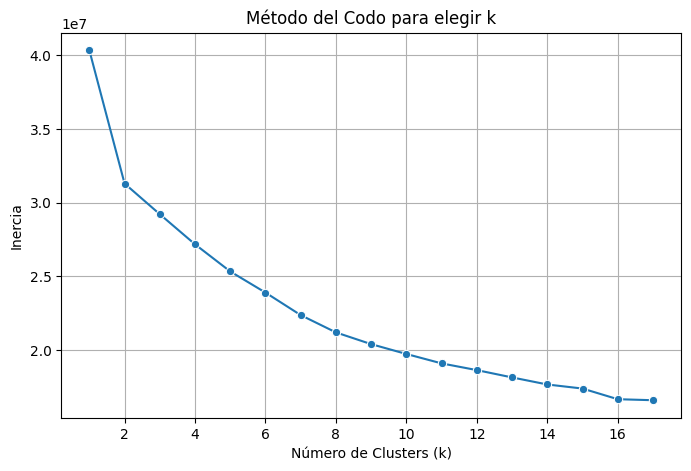

In [ ]:
# Grafica del codo
plt.figure(figsize=(8,5))
sns.lineplot(x=range(1, 18), y=inertia, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para elegir k')
plt.grid(True)
plt.show()

In [ ]:
clientes_encoded

,edad,ingresos_anuales,cantidad_compras,valor_promedio_compra,frecuencia_compras_mensual,dias_desde_ultima_compra,valor_total_gastado,satisfaccion_cliente,participacion_programa_lealtad,dispositivo_utilizado_PC,...,fuente_trafico_email,fuente_trafico_redes sociales,metodo_pago_paypal,metodo_pago_tarjeta crédito,metodo_pago_transferencia,productos_adquiridos_accesorios,productos_adquiridos_computadoras,productos_adquiridos_electrodomésticos,productos_adquiridos_móviles,cluster
0,28,90455,4,135,0.921436,230,3369,2.929789,0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,6
1,35,55842,19,367,5.321630,17,8276,3.446550,1,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2
2,30,23268,39,257,9.021315,13,2216,4.034947,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2
3,35,60841,8,862,2.865878,72,8003,3.466717,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
4,25,100485,19,444,7.365862,57,8550,4.310355,1,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1833326,54,179741,46,52,9.469223,7,3853,4.477112,1,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,4
1833327,45,152344,47,50,8.674232,5,7476,4.258203,1,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,4
1833328,19,19166,19,470,8.919246,8,2794,4.672020,0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,5
1833329,45,54956,6,994,2.550893,150,11215,3.948788,0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,7


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

def gap_statistic(X, nrefs=10, max_clusters=10):
    """
    Calcula Gap Statistic para clustering.
    X: array de datos (n_samples, n_features)
    nrefs: número de simulaciones de referencia
    max_clusters: número máximo de clusters a evaluar
    """
    gaps = []
    results = []

    # límites de los datos
    tops = X.max(axis=0)
    bottoms = X.min(axis=0)

    for k in range(1, max_clusters+1):
        # Ajustar KMeans a los datos reales
        km = KMeans(n_clusters=k, random_state=42).fit(X)
        disp = np.mean(np.min(pairwise_distances(X, km.cluster_centers_), axis=1))

        # Ajustar a datos aleatorios de referencia
        ref_disps = []
        for _ in range(nrefs):
            random_data = np.random.uniform(bottoms, tops, size=X.shape)
            km_ref = KMeans(n_clusters=k, random_state=42).fit(random_data)
            ref_disp = np.mean(np.min(pairwise_distances(random_data, km_ref.cluster_centers_), axis=1))
            ref_disps.append(ref_disp)

        gap = np.log(np.mean(ref_disps)) - np.log(disp)
        gaps.append(gap)
        results.append(disp)

    return np.array(gaps), np.array(results)


#### Gap Statistic

Al aplicar la métrica del Gap Statistic para determinar el número óptimo de clústeres, se observa un comportamiento claro: a partir de 7 clústeres, la ganancia en la calidad de la partición comienza a perder impacto.

En otras palabras, la mejora que se obtiene al aumentar el número de clústeres deja de ser significativa después de este punto, lo que sugiere que k = 7 representa un valor adecuado para capturar la estructura subyacente de los datos sin caer en una sobresegmentación.

# NO CORRER, VALIDACIÓN DE NUMERO DE CLUSTERS, TARDA 40 MIN

In [ ]:
gaps, dispersions = gap_statistic(clientes_norm, nrefs=10, max_clusters=15)

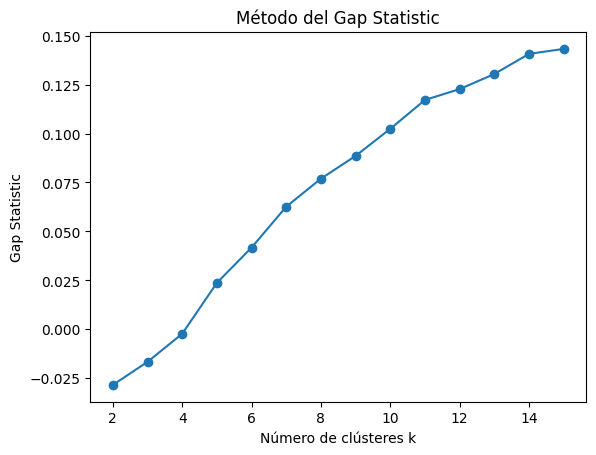

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(2, 16), gaps[1:], marker='o')
plt.xlabel("Número de clústeres k")
plt.ylabel("Gap Statistic")
plt.title("Método del Gap Statistic")
plt.show()

# 5. **Modelado con árbol de decisión**

In [ ]:
## Importar librerías necesarias
## Dataset y funcinones de IA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree
## Procesamiento de datos
import numpy as np
import pandas as pd
## Visualización de datos
import matplotlib.pyplot as plt

In [ ]:
X = clientes_encoded.drop(columns=["cluster"])
y = clientes_encoded["cluster"]

# 2. Transformar categóricas -> variables dummy
X = pd.get_dummies(X, drop_first=True)  # ahora X es todo numérico

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Entrenar modelo
clf = tree.DecisionTreeClassifier(max_depth=4)
clf.fit(X_train, y_train)

print("Precisión en train:", clf.score(X_train, y_train))
print("Precisión en test:", clf.score(X_test, y_test))

Precisión en train: 0.9389812526931867
Precisión en test: 0.9385300558817674


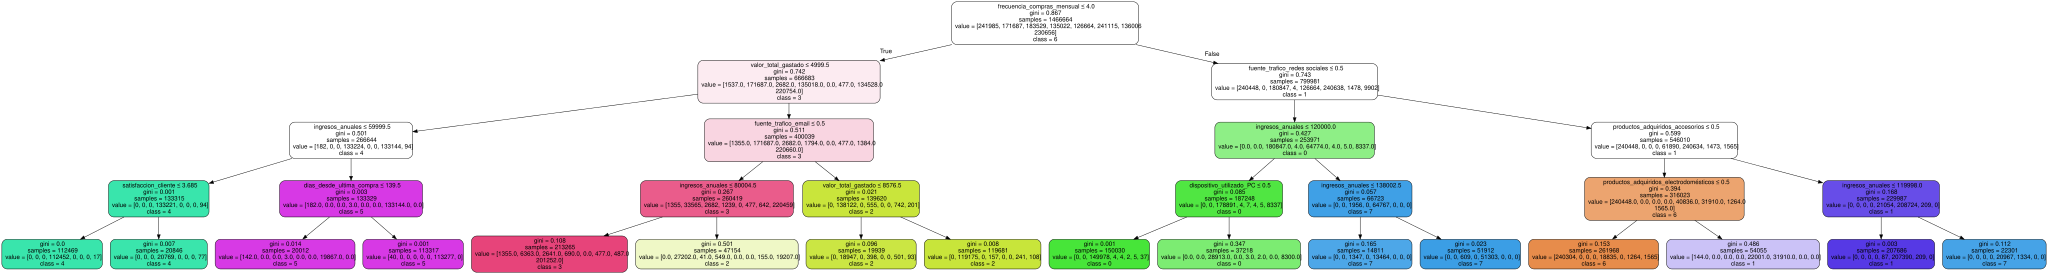

In [ ]:
import graphviz
from sklearn import tree

# Exportar árbol a formato DOT
dot_data = tree.export_graphviz(
    clf,
    out_file=None,
    feature_names=X.columns,
    class_names=y.unique().astype(str),
    filled=True, rounded=True,
    special_characters=True
)

# Generar gráfico
graph = graphviz.Source(dot_data)
graph


In [ ]:
clientes_encoded.columns

Index(['edad', 'ingresos_anuales', 'cantidad_compras', 'valor_promedio_compra',
       'frecuencia_compras_mensual', 'dias_desde_ultima_compra',
       'valor_total_gastado', 'satisfaccion_cliente',
       'participacion_programa_lealtad', 'dispositivo_utilizado_PC',
       'dispositivo_utilizado_móvil', 'dispositivo_utilizado_tablet',
       'fuente_trafico_búsqueda orgánica', 'fuente_trafico_email',
       'fuente_trafico_redes sociales', 'metodo_pago_paypal',
       'metodo_pago_tarjeta crédito', 'metodo_pago_transferencia',
       'productos_adquiridos_accesorios', 'productos_adquiridos_computadoras',
       'productos_adquiridos_electrodomésticos',
       'productos_adquiridos_móviles', 'cluster'],
      dtype='object')

                                   Feature    Importance
1                         ingresos_anuales  2.466381e-01
4               frecuencia_compras_mensual  1.608748e-01
18         productos_adquiridos_accesorios  1.443157e-01
14           fuente_trafico_redes sociales  1.398780e-01
6                      valor_total_gastado  1.380321e-01
13                    fuente_trafico_email  1.164481e-01
20  productos_adquiridos_electrodomésticos  5.120421e-02
9                 dispositivo_utilizado_PC  2.607137e-03
5                 dias_desde_ultima_compra  1.393121e-06
7                     satisfaccion_cliente  3.887899e-07
2                         cantidad_compras  0.000000e+00
3                    valor_promedio_compra  0.000000e+00
0                                     edad  0.000000e+00
8           participacion_programa_lealtad  0.000000e+00
12        fuente_trafico_búsqueda orgánica  0.000000e+00
11            dispositivo_utilizado_tablet  0.000000e+00
10             dispositivo_util

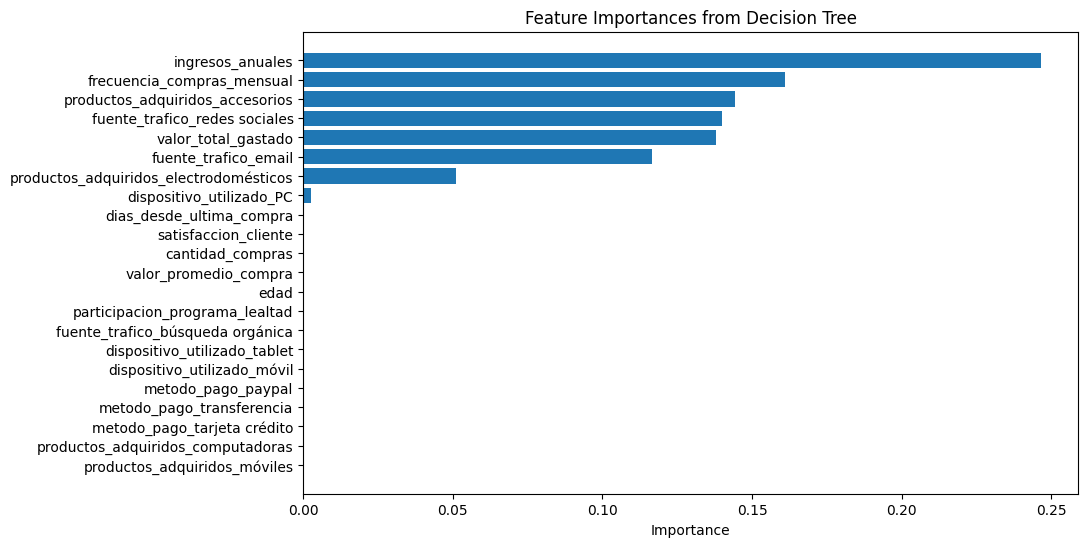

In [ ]:

importances = clf.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importances from Decision Tree")
plt.gca().invert_yaxis()
plt.show()


Al utilizar el modelo de árbol de decisión se puede observar que es uitlizan 8 variables para poder generar la ramas de este modelo.
La más importante de estas variables, es decir, la que hace la clasificación más grandes son los ingresos anuales, sin embargo, esta variable no es la uitlizada al inicio del árbol, sino que está presente en múltiples ramas en nivles distintos del árbol.
La segunda variables más relevante es la frecuencia de compras mensual, es variable es utilizada al inicio del árbol para separar en dos clases que posteriormente son clasificadas por medio de variables como si se adquirió o no un accesorio, si la fuente de tráfico fue búsqueda organica o no, el valor total gastado, si la fuente de tráfico fue email o no, si los productos adquiridos fueron electrodomésticos y si el dispositivo utilizado fue el computador personal (PC)

Algunas cosas que nos llamaron la atención atención fueron los siguientes hechos:
- Si se hacía la clasificación con una menor cantidad de clústers (dígase 4), se necesita una menor profundidad de árbol y se podía alcanzar una métrica de evaluacíon del modelo muy similar, esto generó la duda de si era suficiente contar con este número de clases/clústers dado que el modelo tenía un "buen desempeño".
- Al hacer la clasificación con un número menor de clústers los importances del modelo cambiaban.
- Las variables continua parecieran ser las que el modelo les da una mayor importancia inicial a pesar de que en el proceso de perfilamiento (unas celdas más adelante), las categóricas permitían entender mejor al cliente.
- Hay muchas variables que tienen un importance con un valor de 0, lo cuál llevaría a pensar si se podrían obviar al momento de modelar.
- Al ir más profundo en el árbol, la pureza de los nodos (basado en el valor del índice Gini) no tiene a ser "más puro" conforme se desciende en el modelo, sino que aumenta y disminuye en cada nivel dependiendo del caso.


In [ ]:
  def get_product_list(row):
    products = []
    if row['productos_adquiridos_accesorios'] == 1:
        products.append('accesorios')
    if row['productos_adquiridos_computadoras'] == 1:
        products.append('computadoras')
    if row['productos_adquiridos_electrodomésticos'] == 1:
        products.append('electrodomésticos')
    if row['productos_adquiridos_móviles'] == 1:
        products.append('móviles')
    return ', '.join(products) if products else None


if all(col in clientes_encoded.columns for col in ['dispositivo_utilizado_PC', 'dispositivo_utilizado_móvil', 'dispositivo_utilizado_tablet']):
    clientes_encoded['dispositivo_utilizado'] = clientes_encoded[
        ['dispositivo_utilizado_PC', 'dispositivo_utilizado_móvil', 'dispositivo_utilizado_tablet']
    ].idxmax(axis=1).str.replace('dispositivo_utilizado_', '')

if all(col in clientes_encoded.columns for col in ['fuente_trafico_búsqueda orgánica', 'fuente_trafico_email', 'fuente_trafico_redes sociales']):
    clientes_encoded['fuente_trafico'] = clientes_encoded[
        ['fuente_trafico_búsqueda orgánica', 'fuente_trafico_email', 'fuente_trafico_redes sociales']
    ].idxmax(axis=1).str.replace('fuente_trafico_', '')

if all(col in clientes_encoded.columns for col in ['metodo_pago_paypal', 'metodo_pago_tarjeta crédito', 'metodo_pago_transferencia']):
    clientes_encoded['metodo_pago'] = clientes_encoded[
        ['metodo_pago_paypal', 'metodo_pago_tarjeta crédito', 'metodo_pago_transferencia']
    ].idxmax(axis=1).str.replace('metodo_pago_', '')

if all(col in clientes_encoded.columns for col in ['productos_adquiridos_accesorios', 'productos_adquiridos_computadoras', 'productos_adquiridos_electrodomésticos', 'productos_adquiridos_móviles']):
    clientes_encoded['productos_adquiridos'] = clientes_encoded.apply(get_product_list, axis=1)


cols_to_drop = [
    'dispositivo_utilizado_PC', 'dispositivo_utilizado_móvil', 'dispositivo_utilizado_tablet',
    'fuente_trafico_búsqueda orgánica', 'fuente_trafico_email', 'fuente_trafico_redes sociales',
    'metodo_pago_paypal', 'metodo_pago_tarjeta crédito', 'metodo_pago_transferencia',
    'productos_adquiridos_accesorios', 'productos_adquiridos_computadoras',
    'productos_adquiridos_electrodomésticos', 'productos_adquiridos_móviles'
]
clientes_encoded.drop(columns=[col for col in cols_to_drop if col in clientes_encoded.columns], inplace=True)


clientes_encoded['cluster'] = clientes_encoded['cluster'].astype('category')

cluster_dfs = {cluster: clientes_encoded[clientes_encoded['cluster'] == cluster] for cluster in clientes_encoded['cluster'].cat.categories}

In [ ]:

cluster_0_df = cluster_dfs[0]
cluster_1_df = cluster_dfs[1]
cluster_2_df = cluster_dfs[2]
cluster_3_df = cluster_dfs[3]
cluster_4_df = cluster_dfs[4]
cluster_5_df = cluster_dfs[5]
cluster_6_df = cluster_dfs[6]

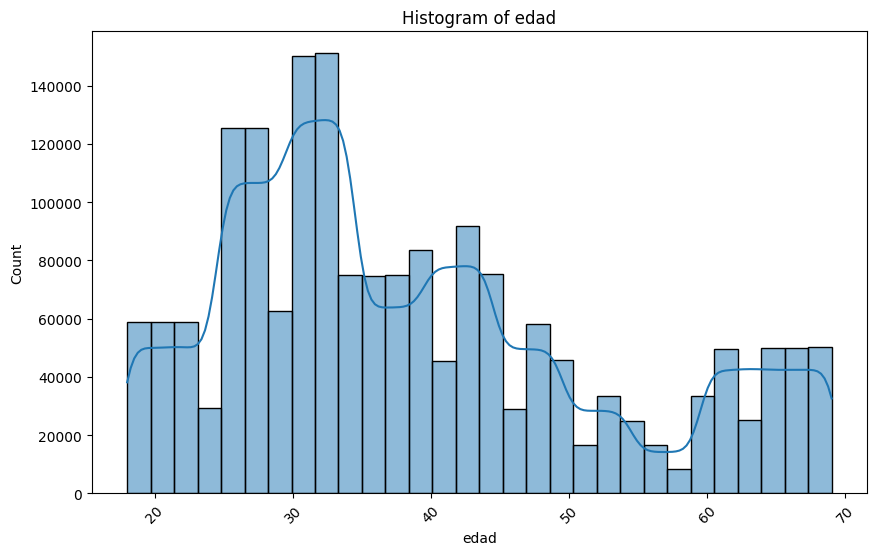

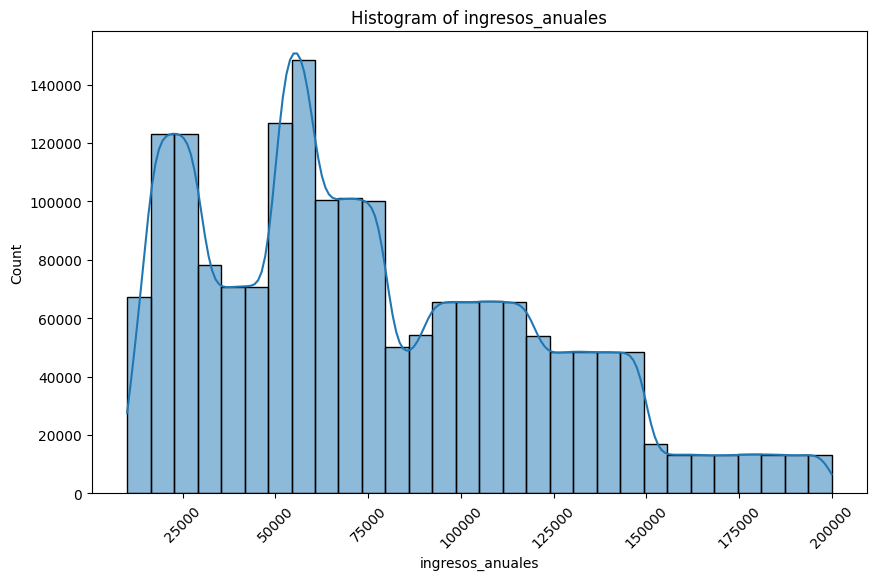

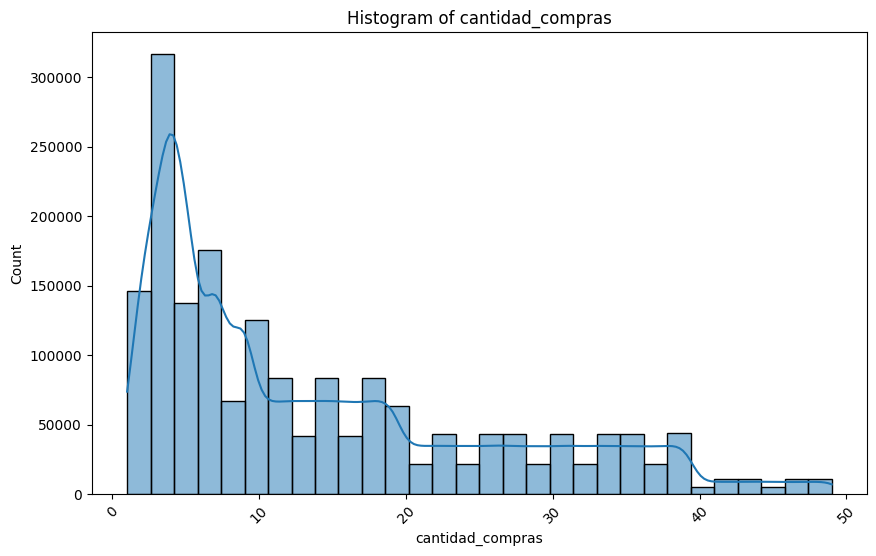

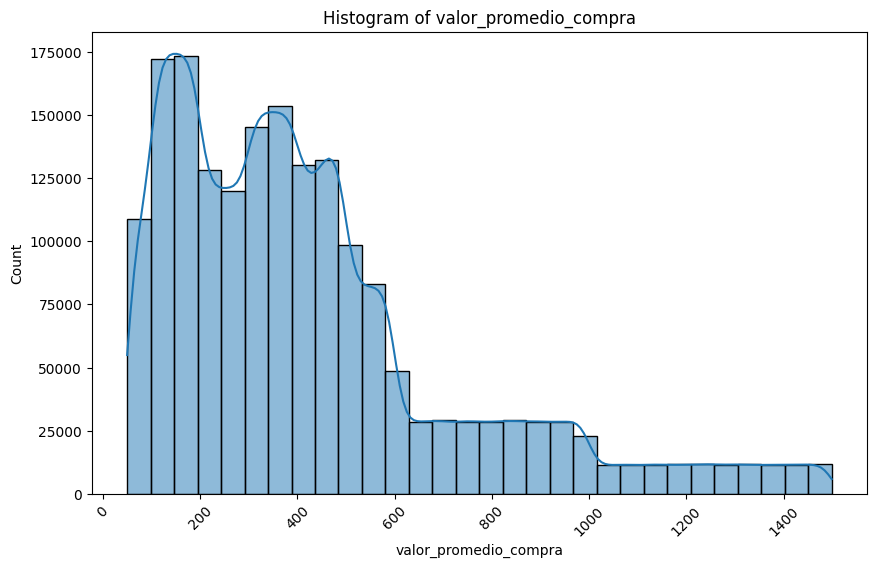

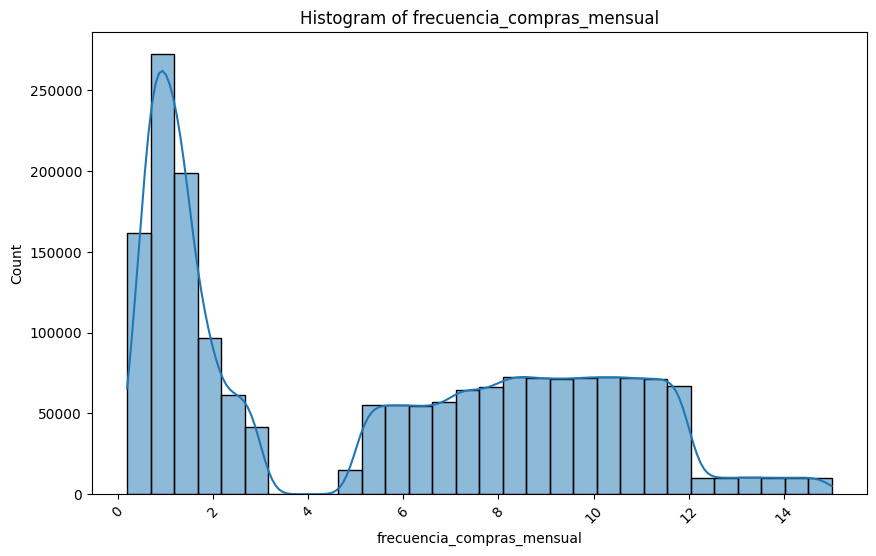

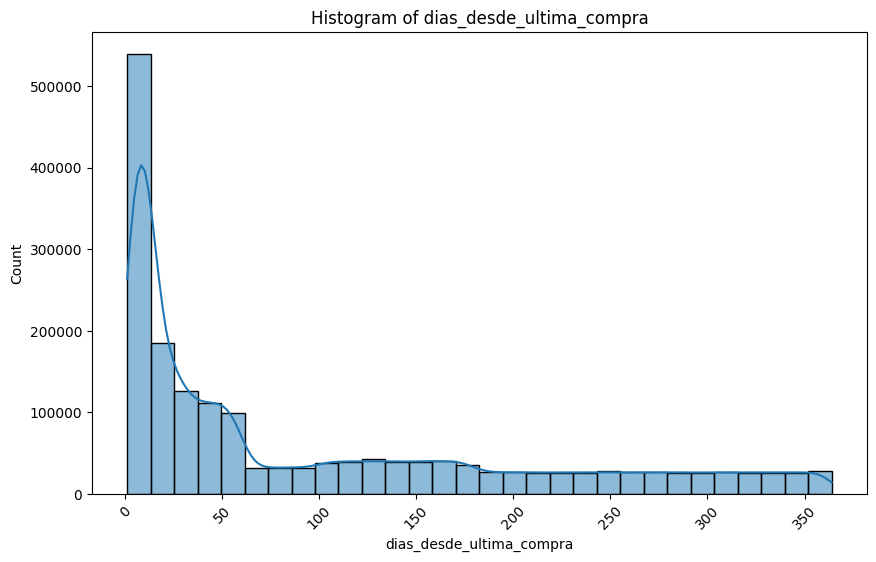

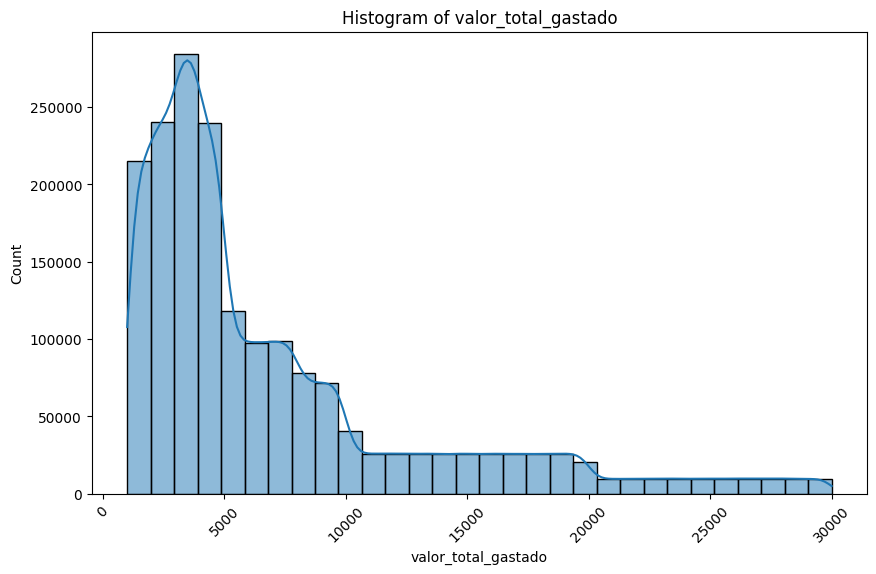

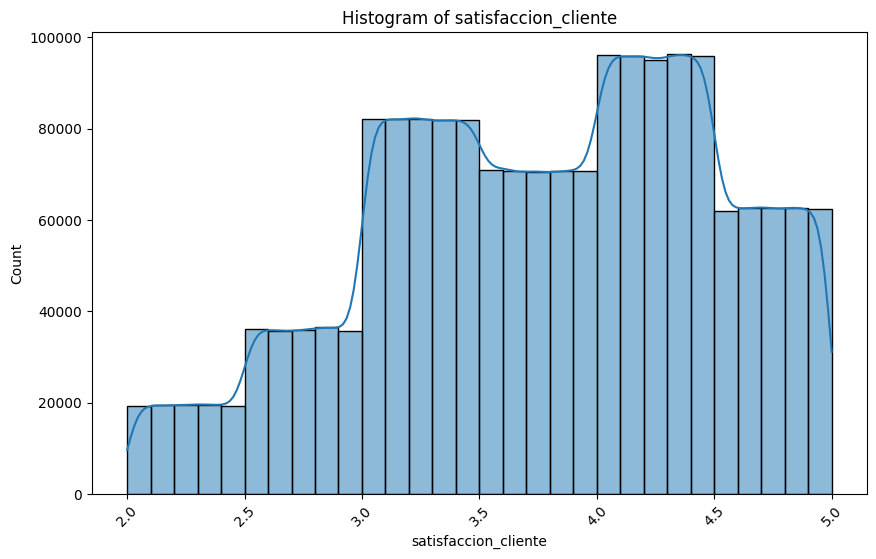

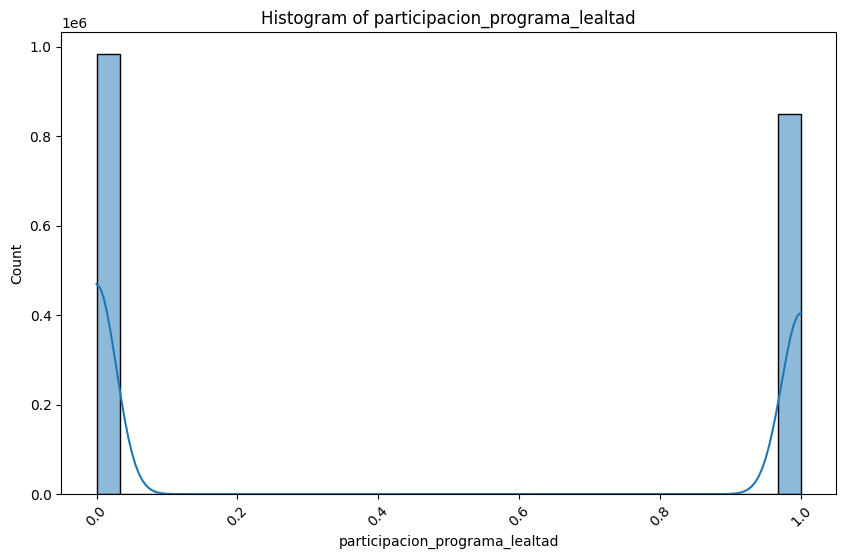

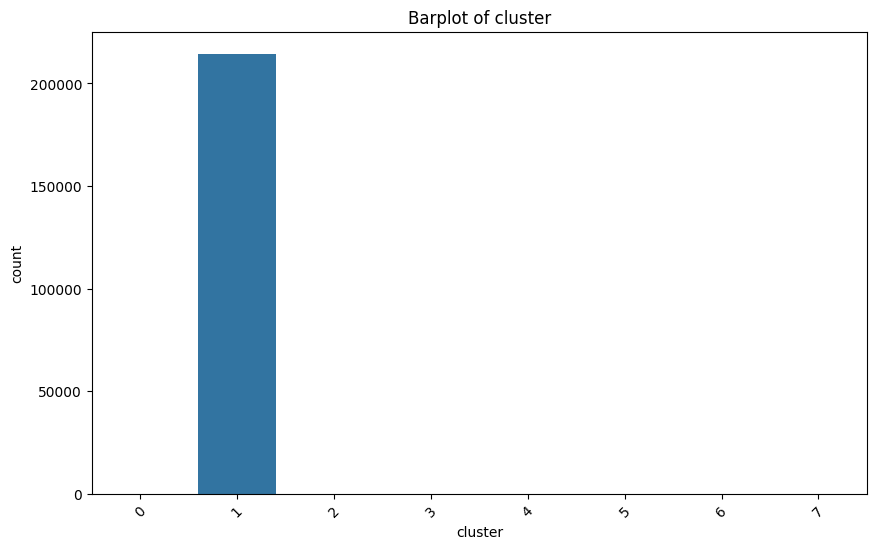

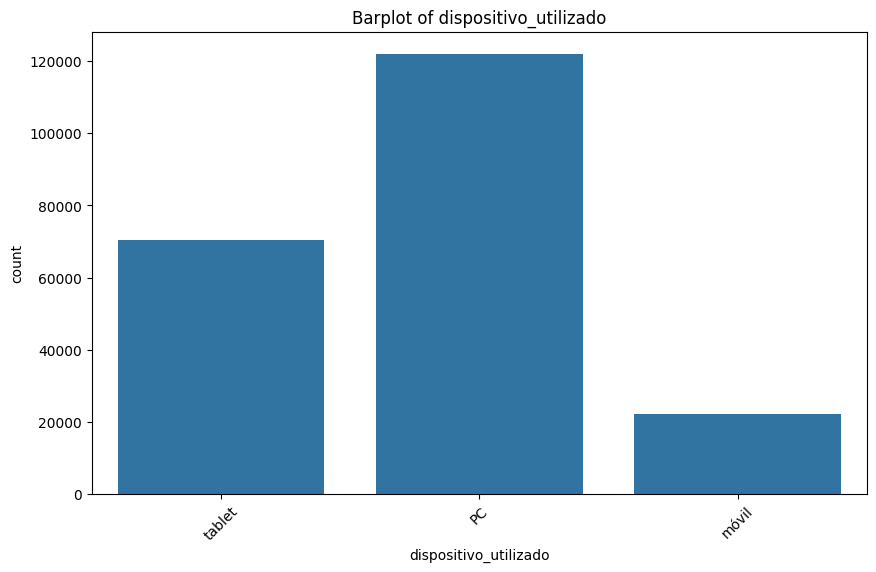

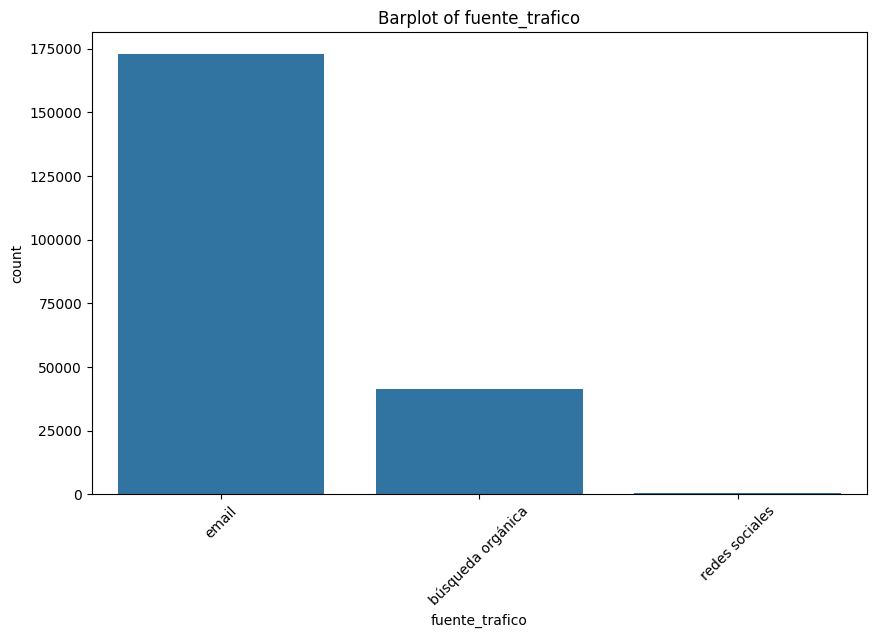

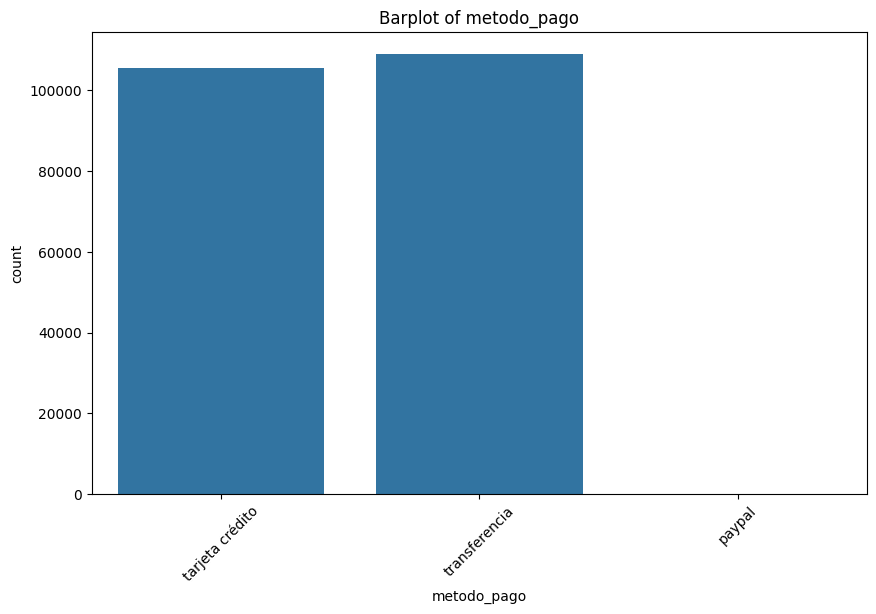

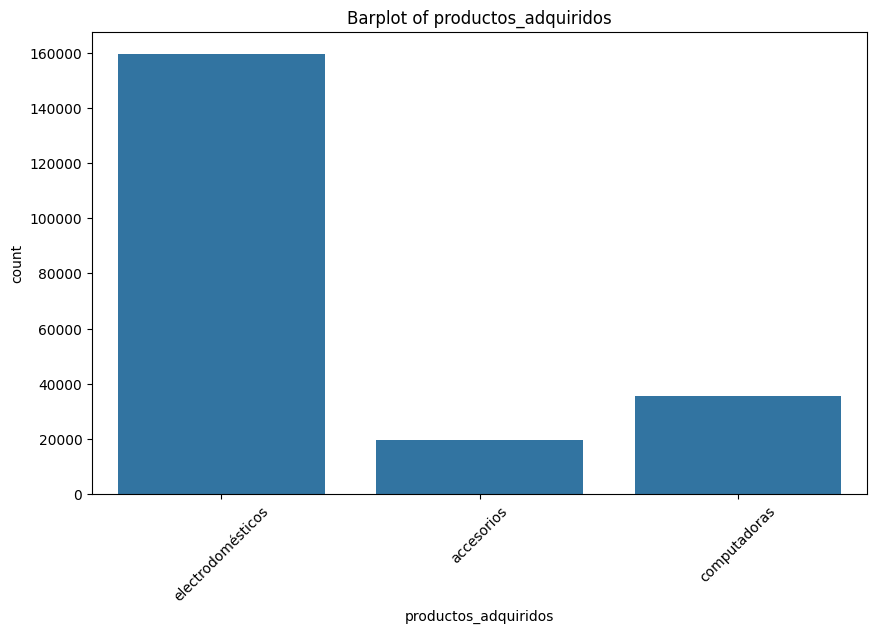

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

categorical_clientes = cluster_1_df.select_dtypes(exclude=['number'])

def plot_distribution(cluster_1_df):
    for column in cluster_1_df.columns:
        plt.figure(figsize=(10, 6))

        if cluster_1_df[column].dtype in ['int64', 'float64']:
            sns.histplot(cluster_1_df[column], kde=True, bins=30)
            plt.title(f'Histogram of {column}')

        else:
            sns.countplot(x=cluster_1_df[column])
            plt.title(f'Barplot of {column}')

        plt.xticks(rotation=45)
        plt.show()

plot_distribution(numeric_clientes)
plot_distribution(categorical_clientes)

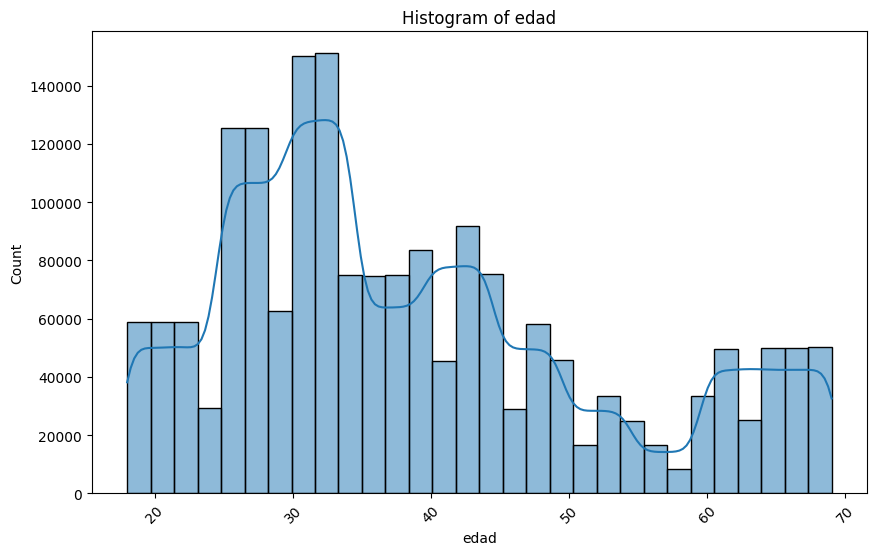

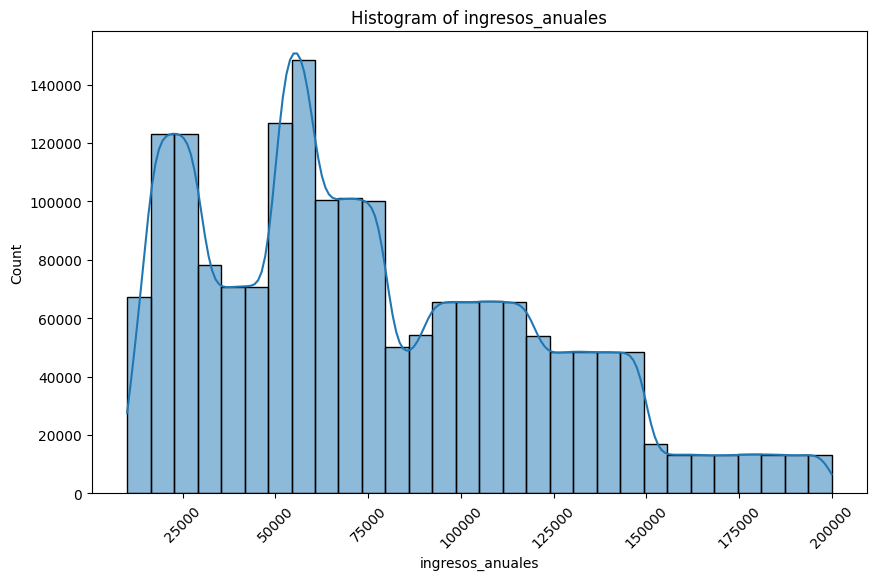

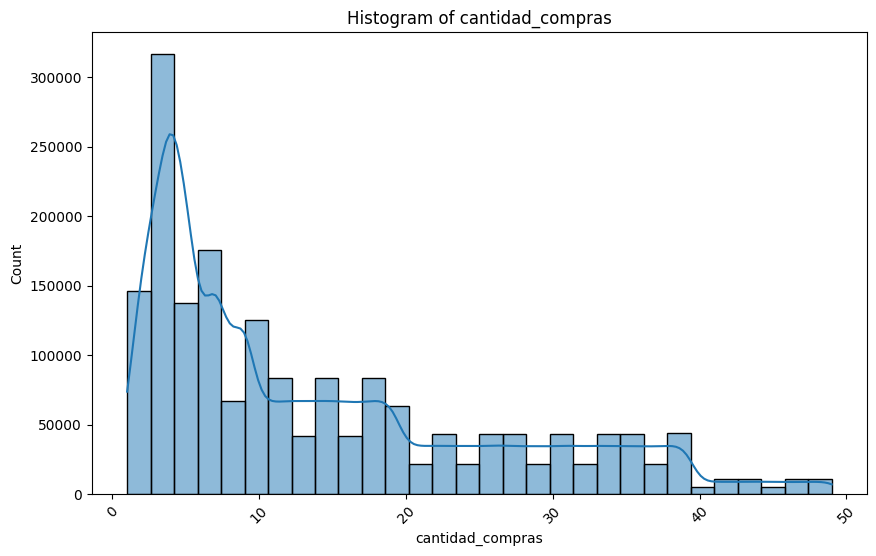

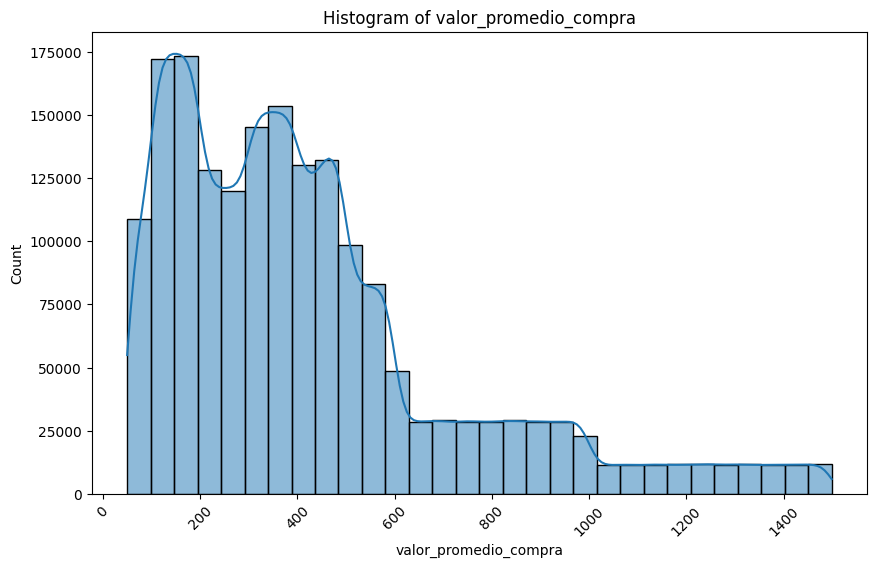

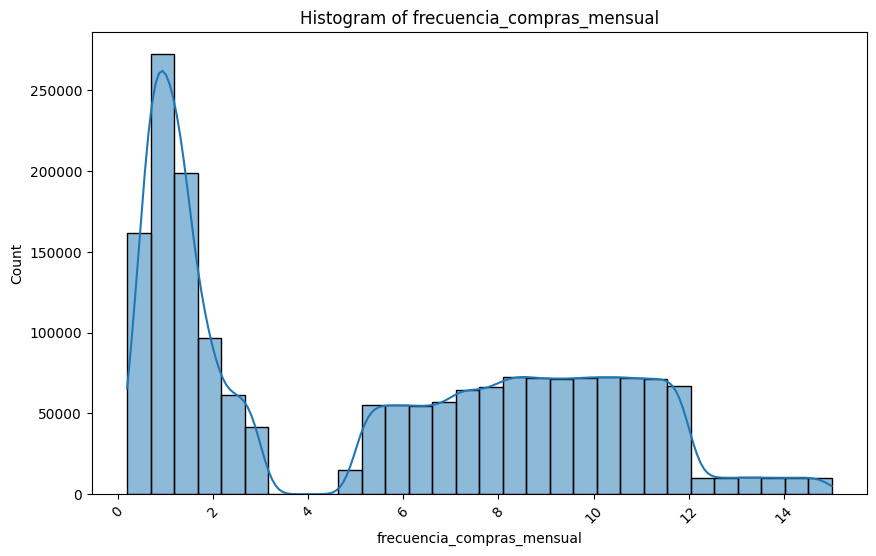

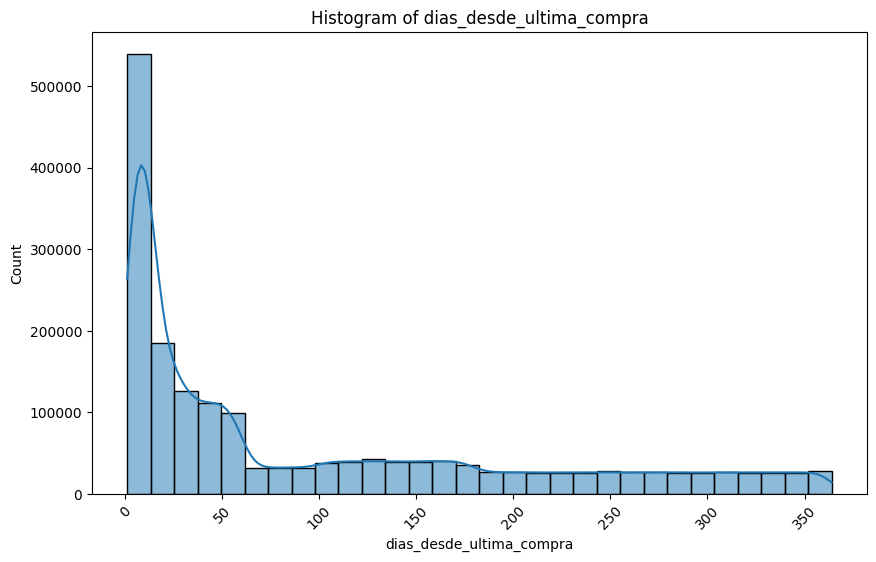

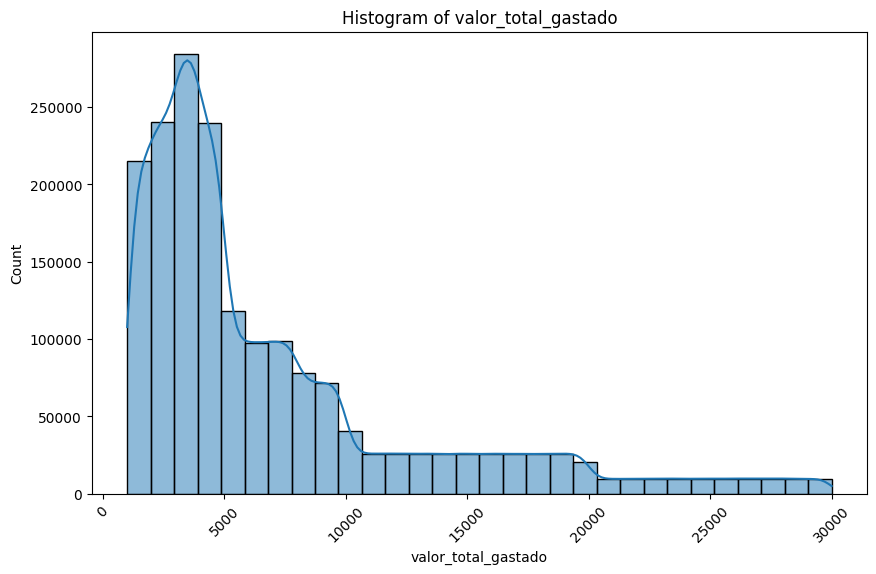

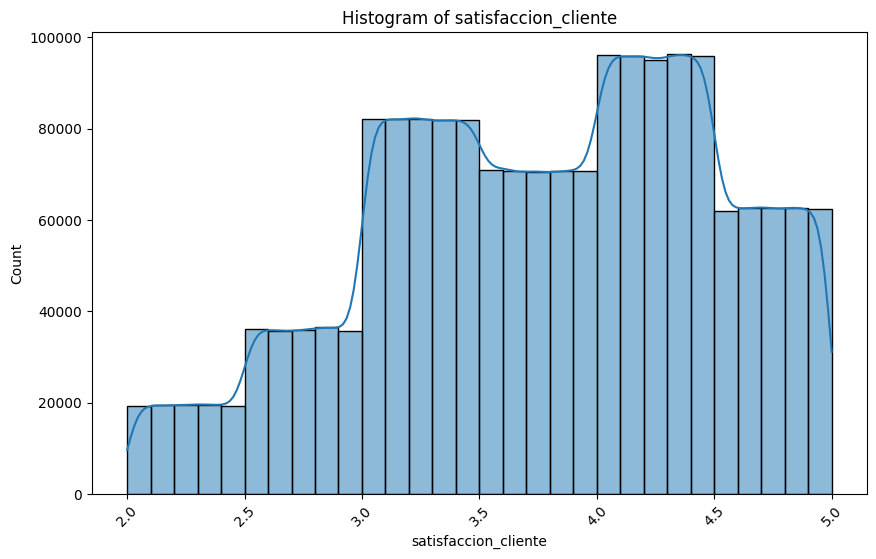

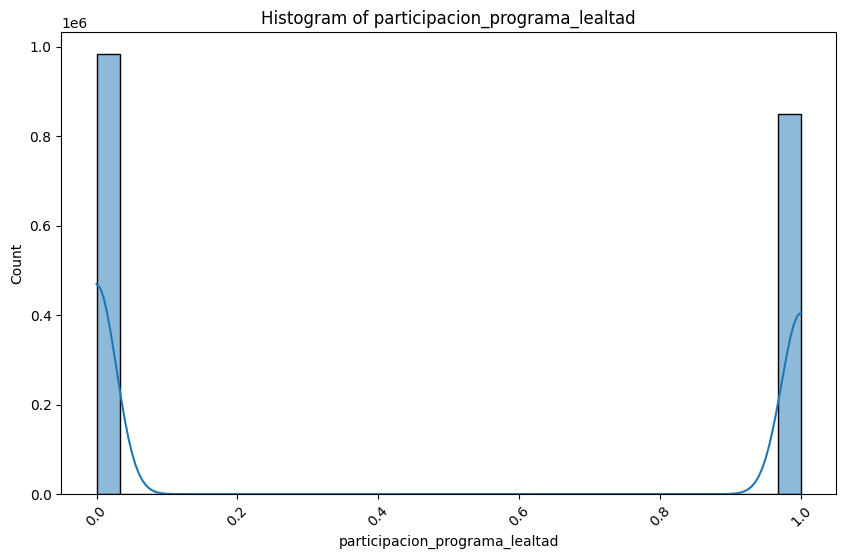

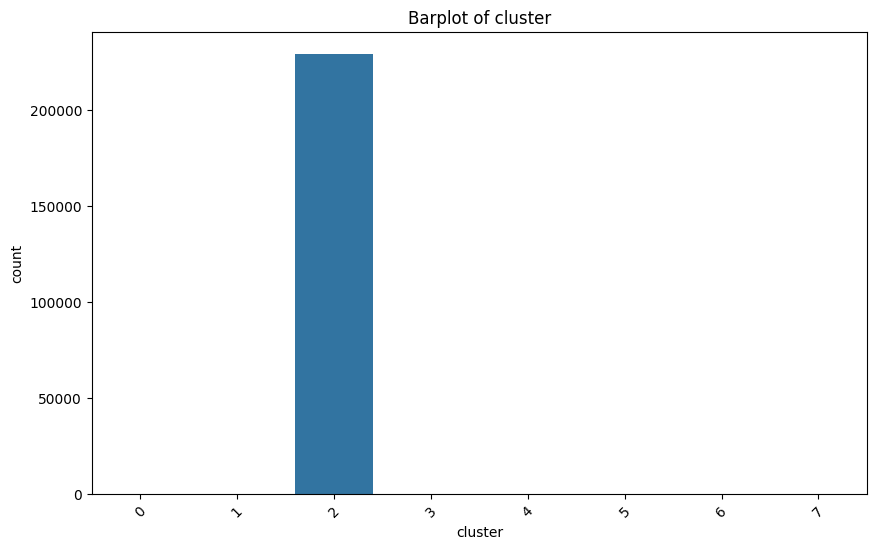

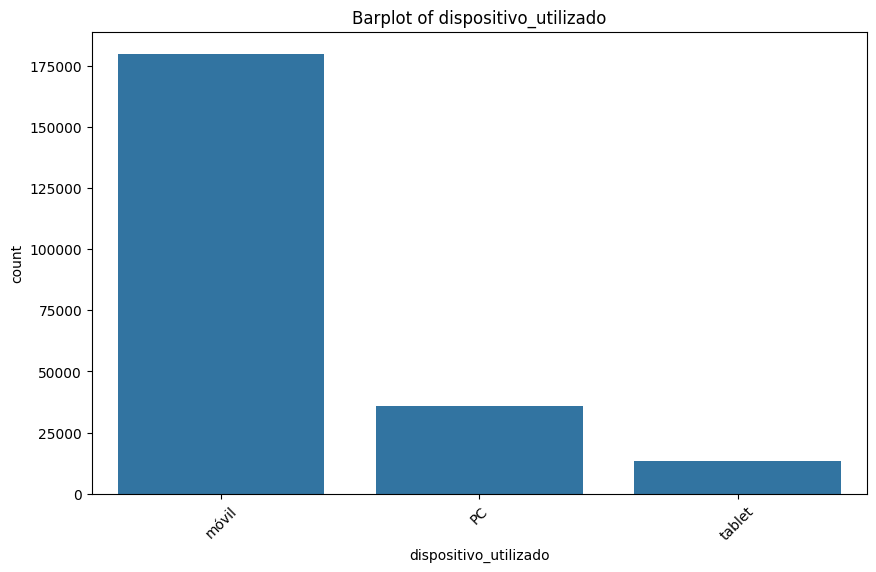

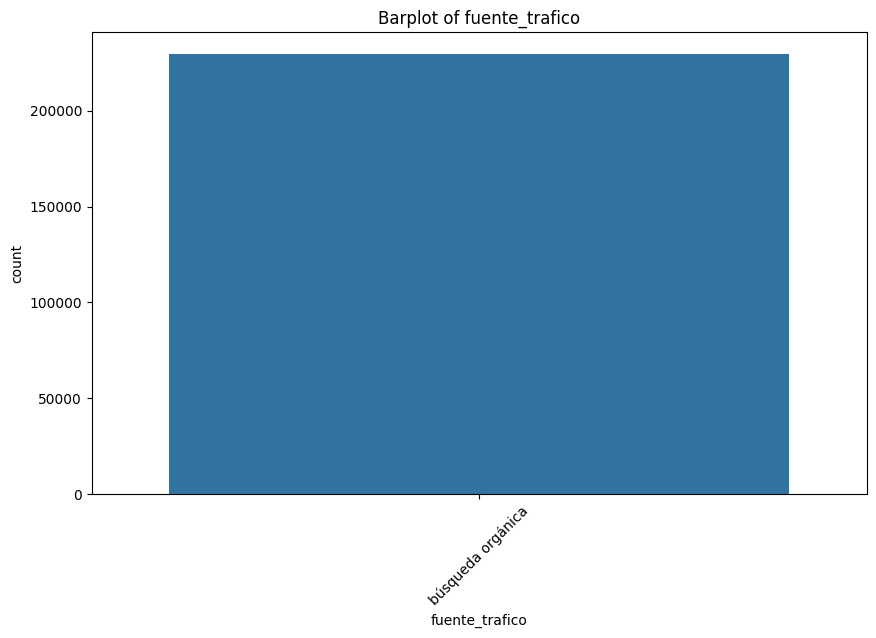

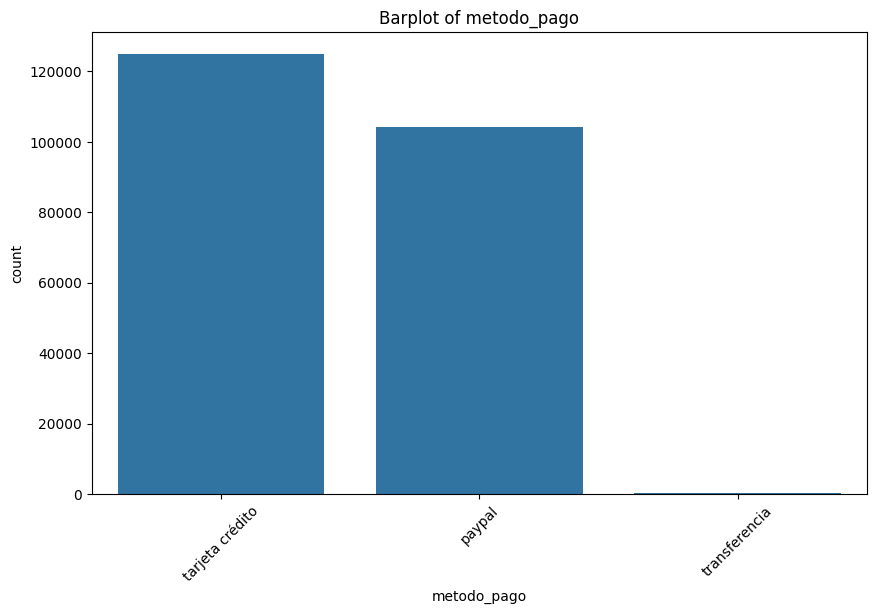

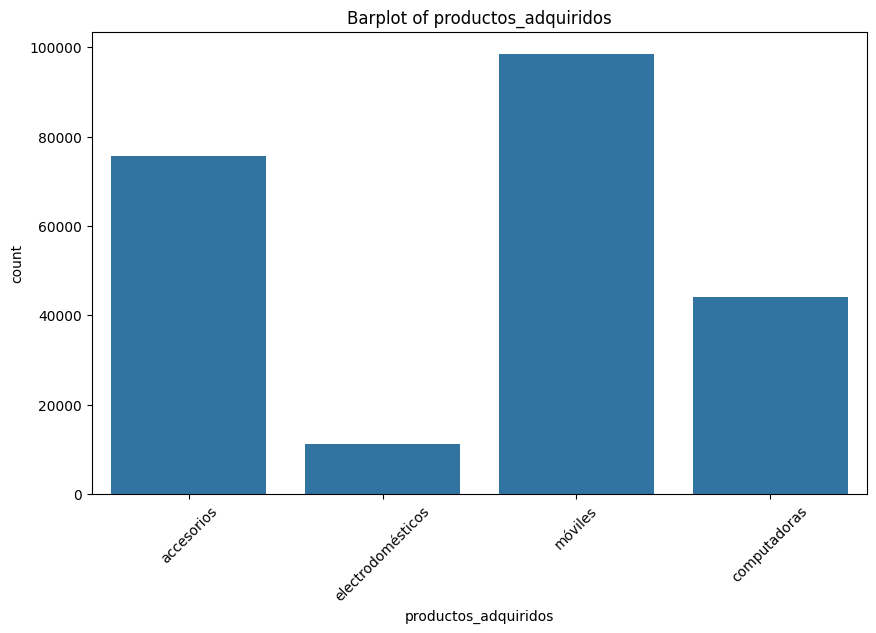

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

categorical_clientes = cluster_2_df.select_dtypes(exclude=['number'])

def plot_distribution(df):
    for column in df.columns:
        plt.figure(figsize=(10, 6))

        if df[column].dtype in ['int64', 'float64']:
            sns.histplot(df[column], kde=True, bins=30)
            plt.title(f'Histogram of {column}')

        else:
            sns.countplot(x=df[column])
            plt.title(f'Barplot of {column}')

        plt.xticks(rotation=45)
        plt.show()

plot_distribution(numeric_clientes)
plot_distribution(categorical_clientes)

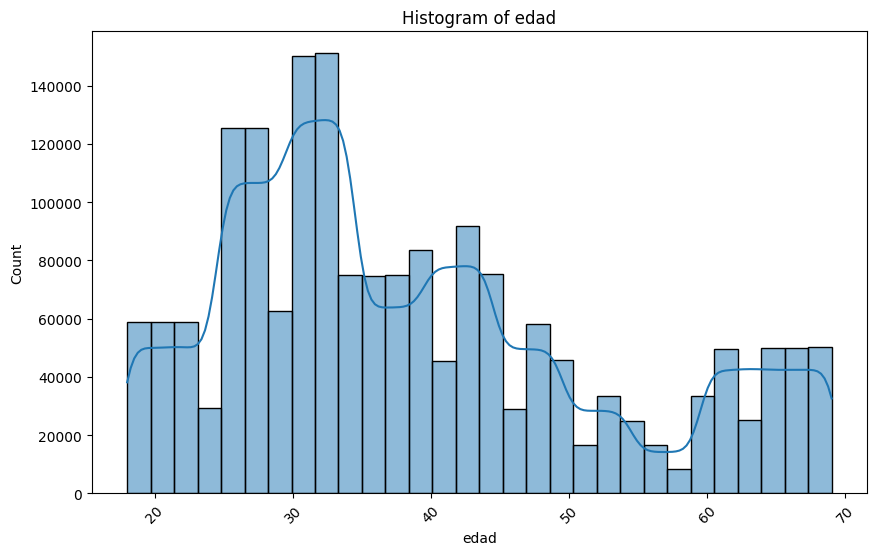

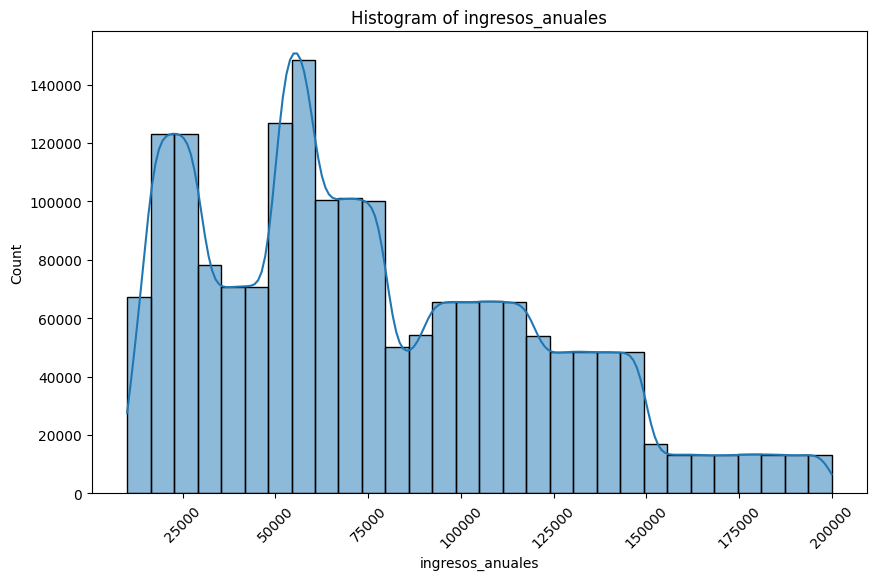

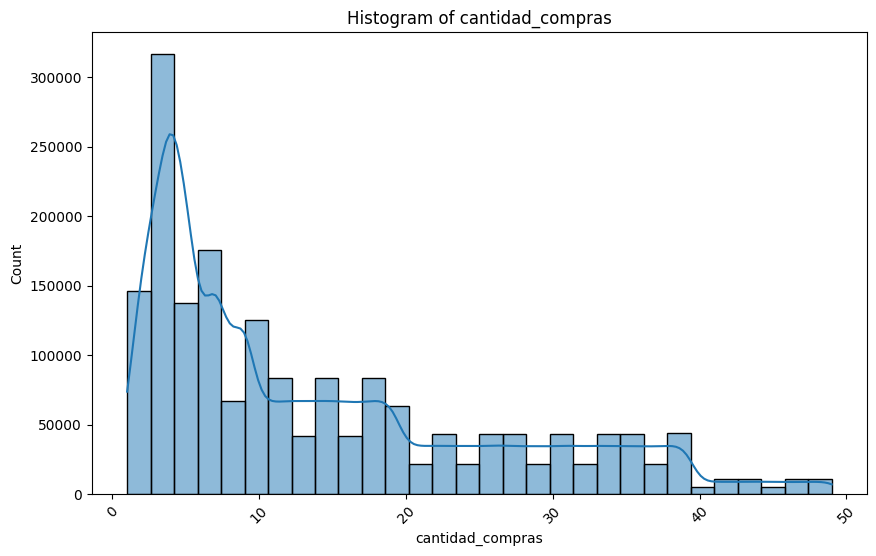

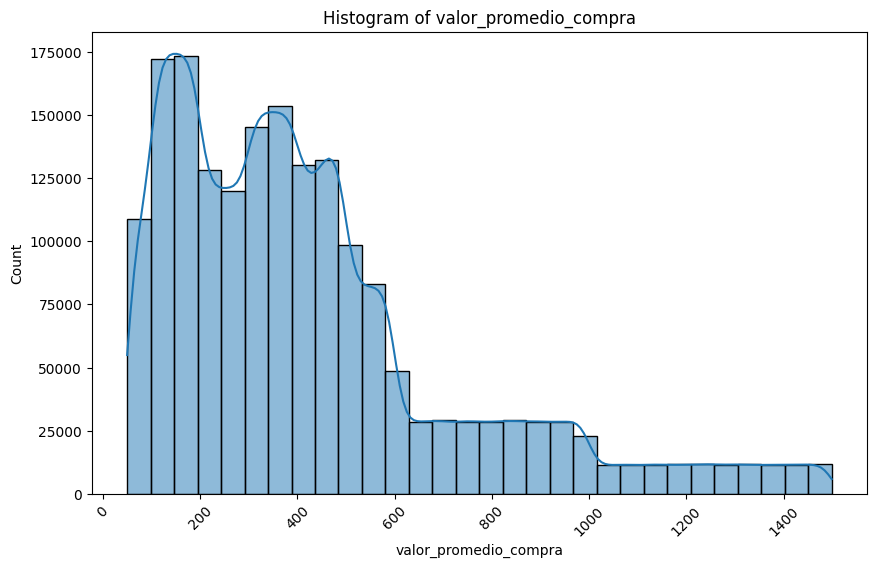

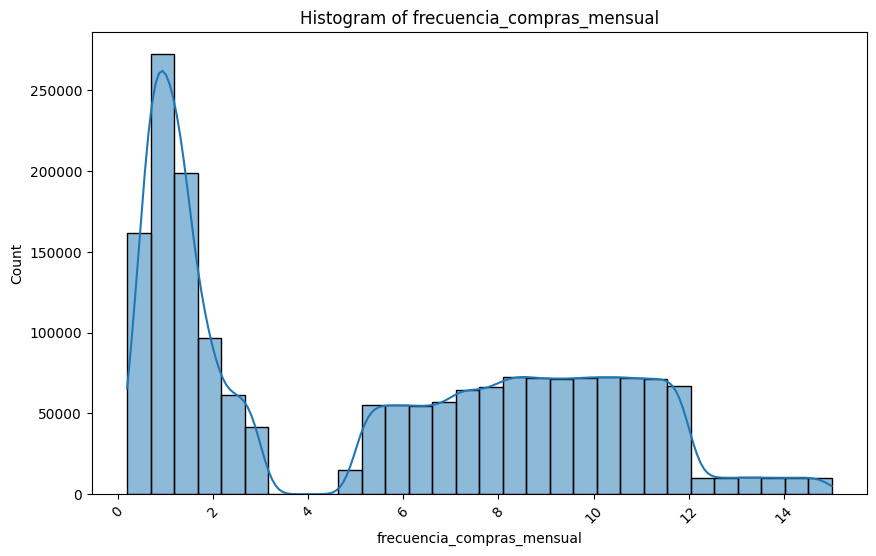

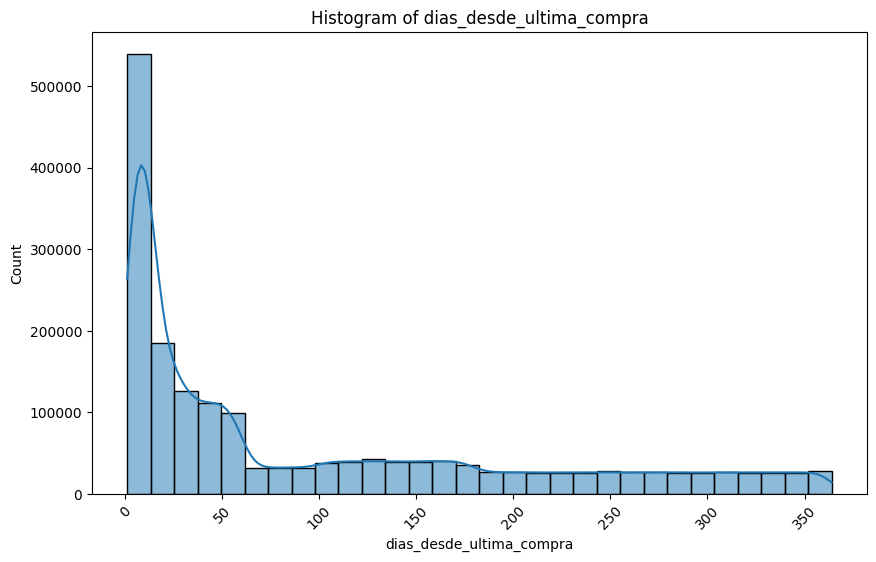

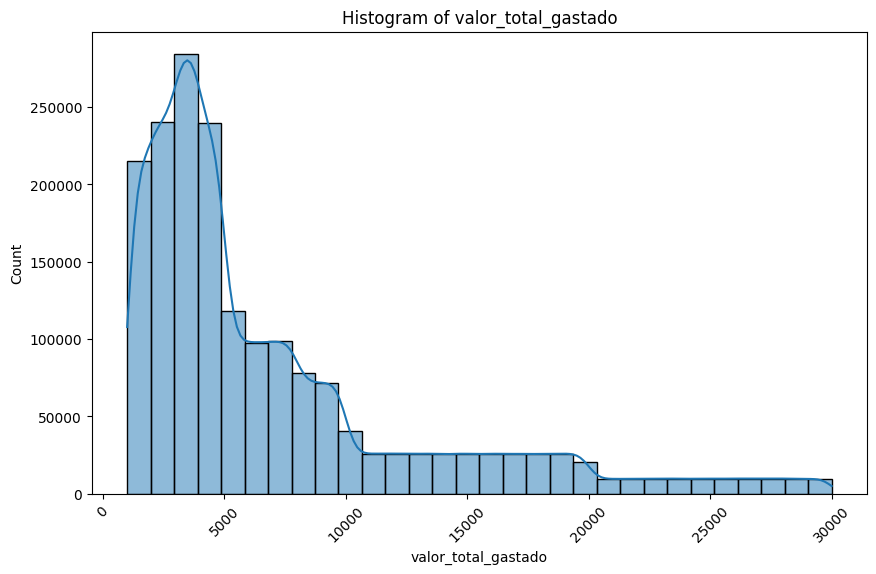

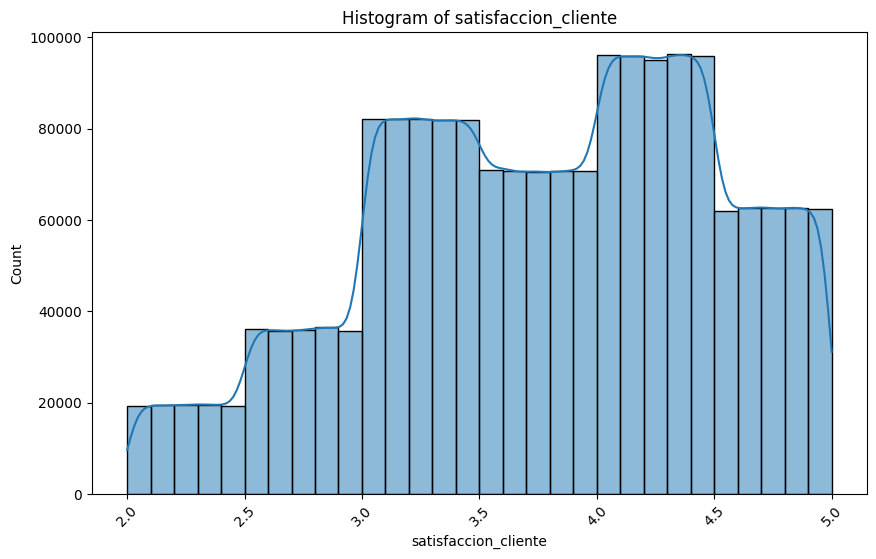

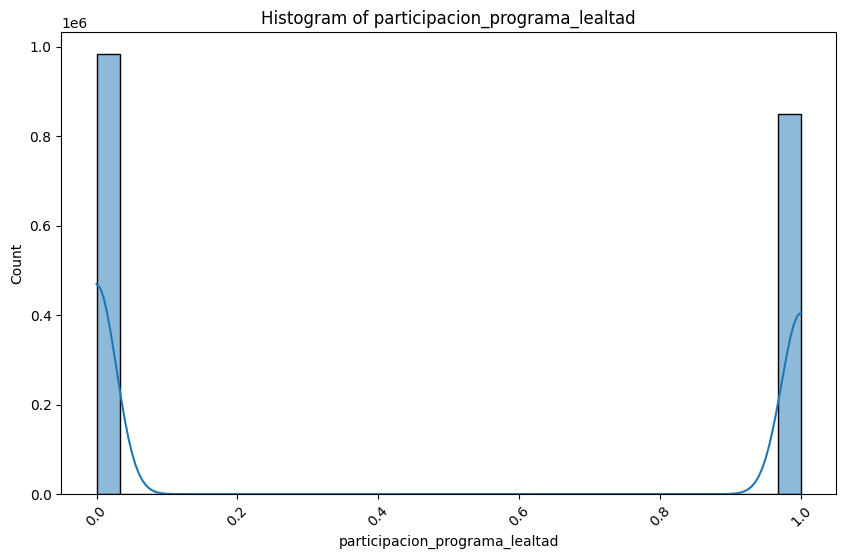

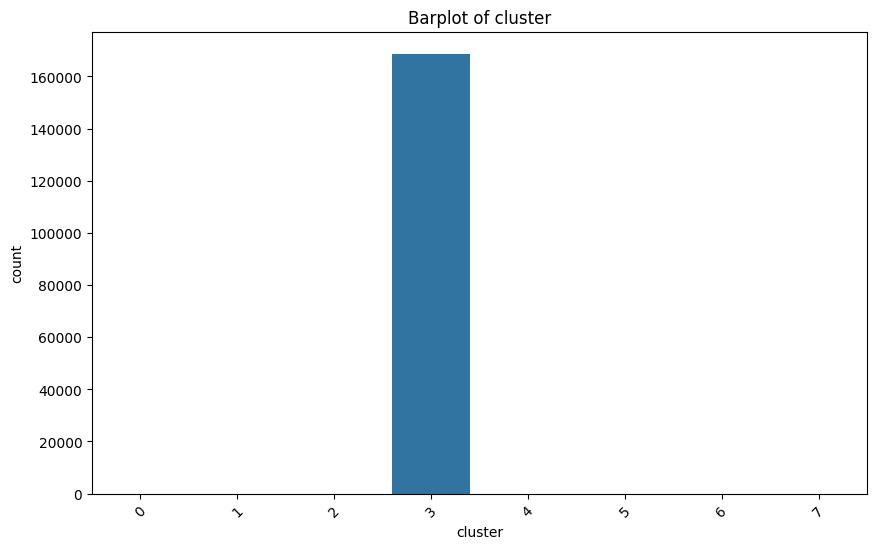

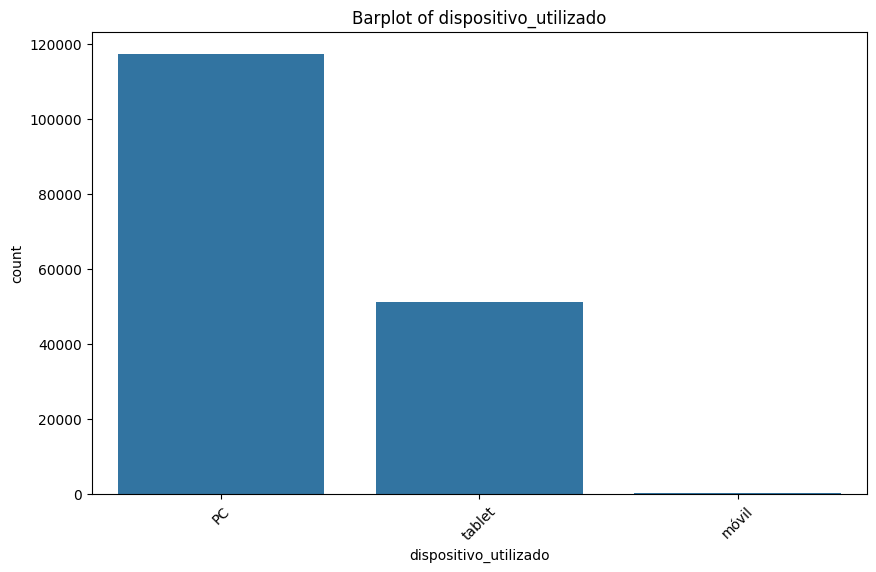

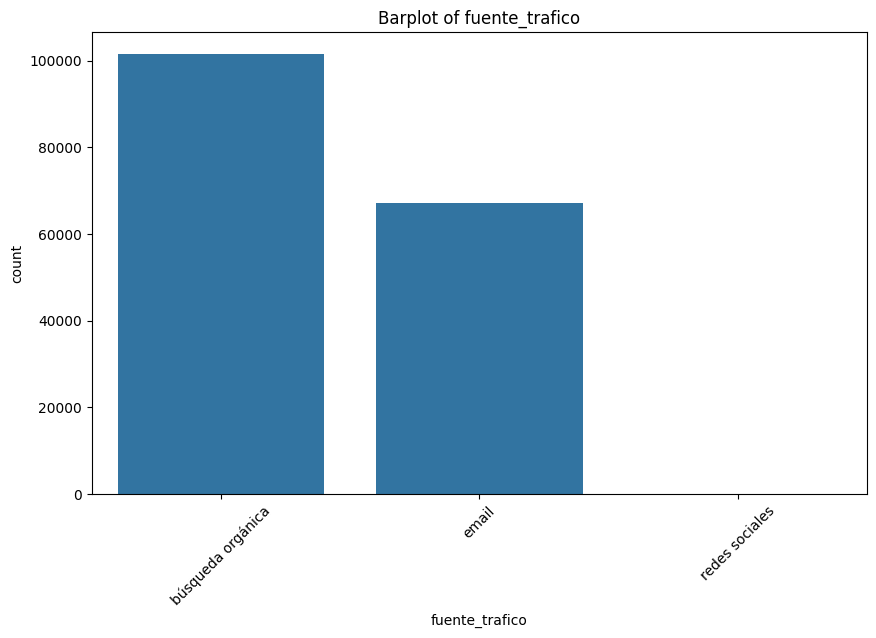

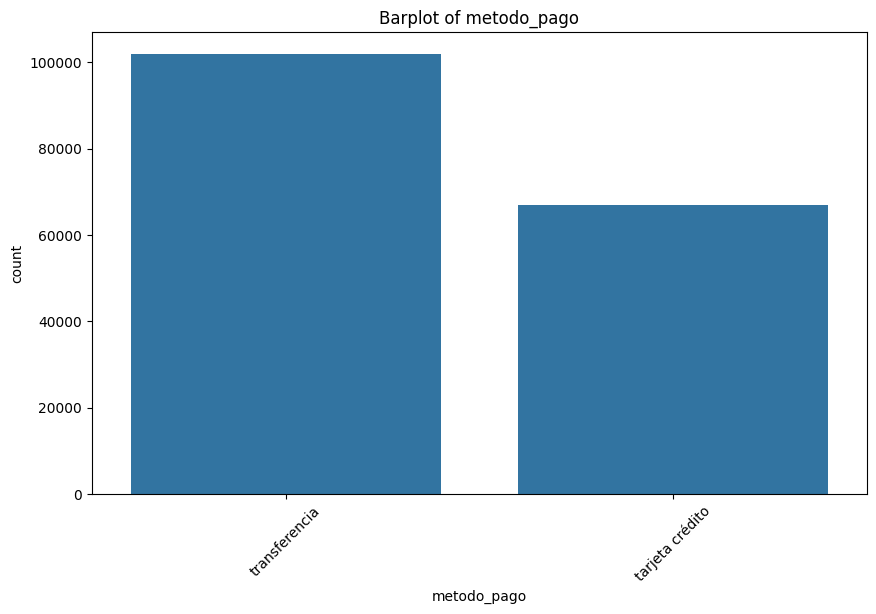

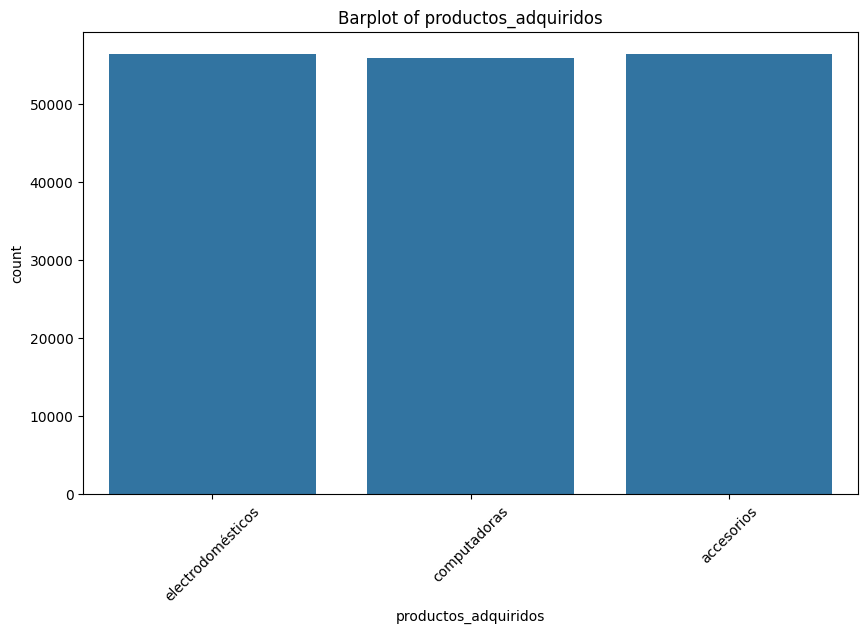

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

categorical_clientes = cluster_3_df.select_dtypes(exclude=['number'])

def plot_distribution(df):
    for column in df.columns:
        plt.figure(figsize=(10, 6))

        if df[column].dtype in ['int64', 'float64']:
            sns.histplot(df[column], kde=True, bins=30)
            plt.title(f'Histogram of {column}')

        else:
            sns.countplot(x=df[column])
            plt.title(f'Barplot of {column}')

        plt.xticks(rotation=45)
        plt.show()

plot_distribution(numeric_clientes)
plot_distribution(categorical_clientes)

# Metedo de histograma
No se observo como tal una diferenciación entre las variables numericas con este grafico, se vio más en las categoricas. Sin embargo, su visualización es algo torpe y puede confundir. Por ende se probara con graficos de violin que muestran distribución completa (densidad) y no solo cuartiles como el boxplot. Así ves si un clúster tiene colas largas, multimodalidad o mucha dispersión, además de comparar medianas entre clústeres. Ademas, usar barras apiladas en las categoricas para: comparan la composición interna de cada clúster en una misma escala (0–100%).



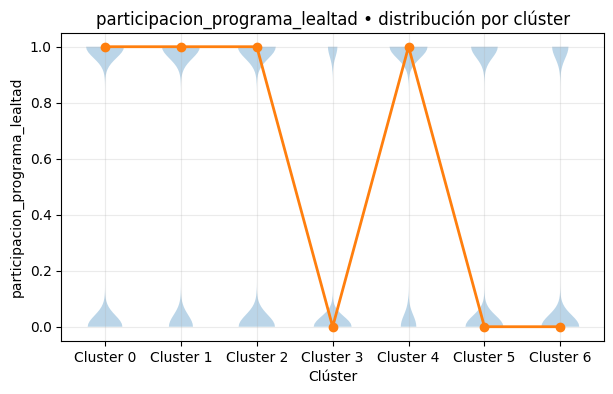

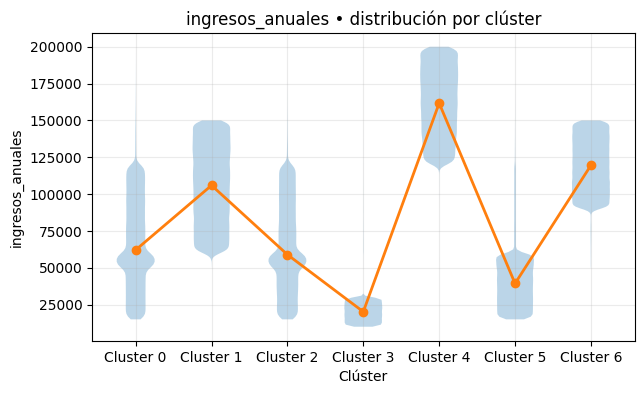

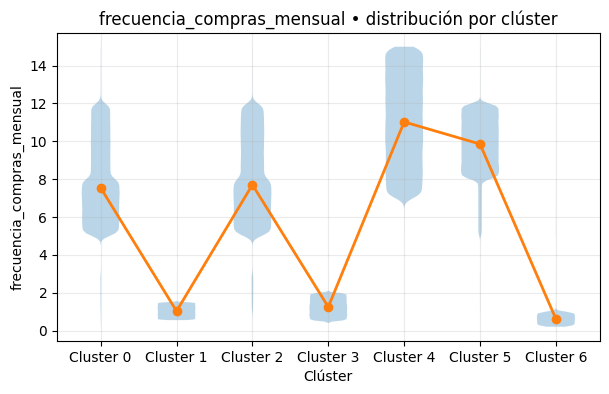

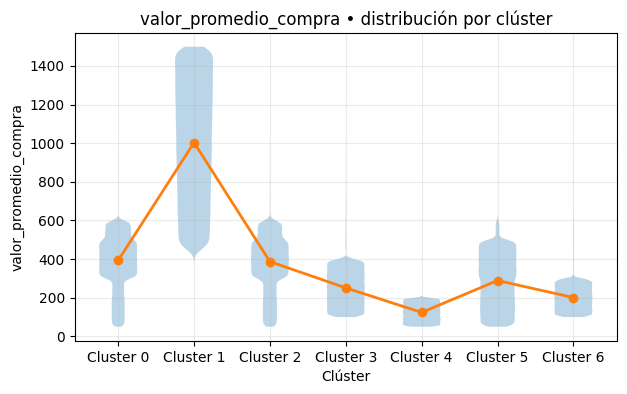

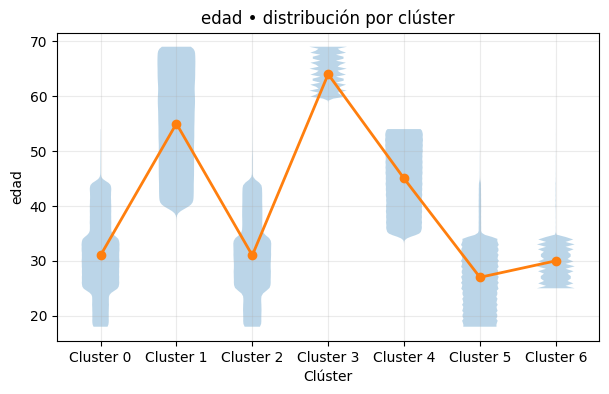

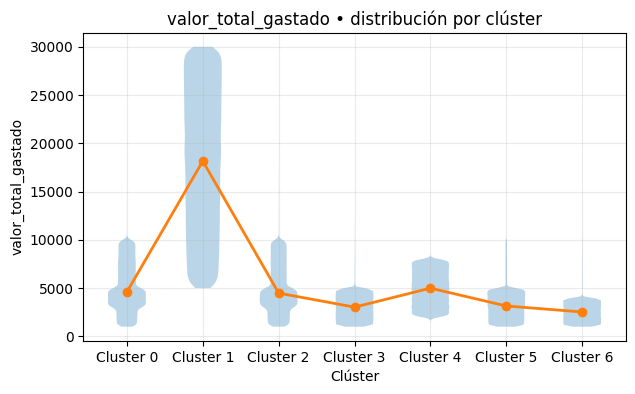

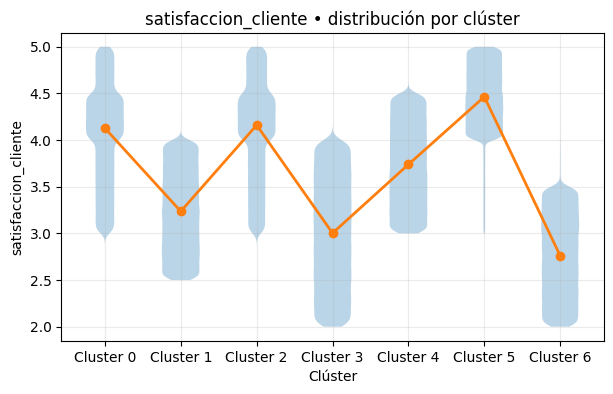

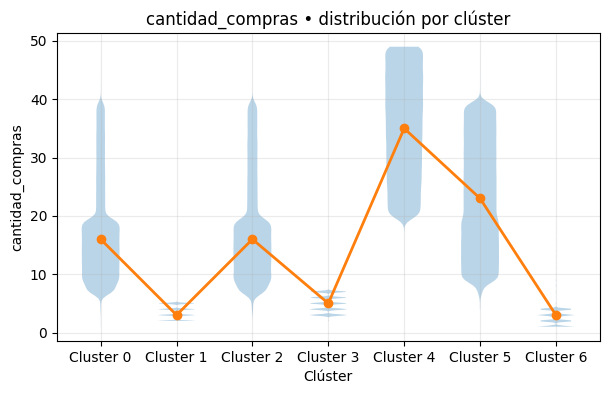

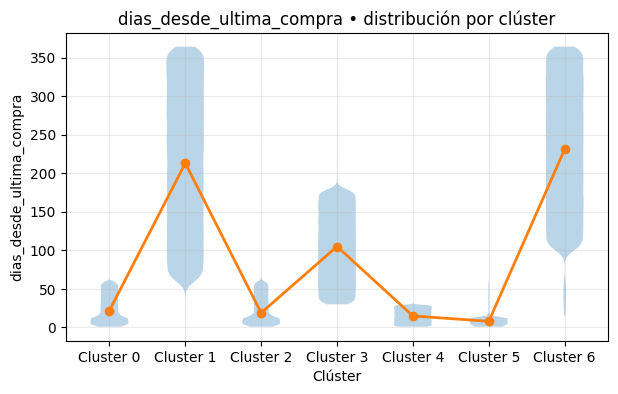

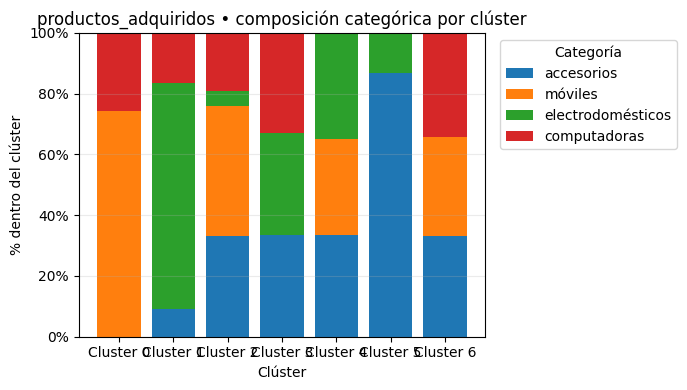

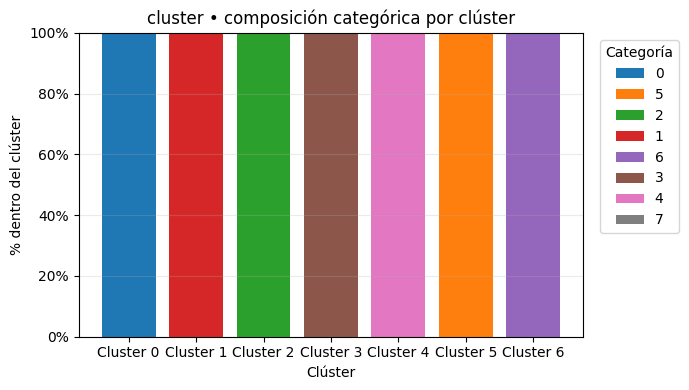

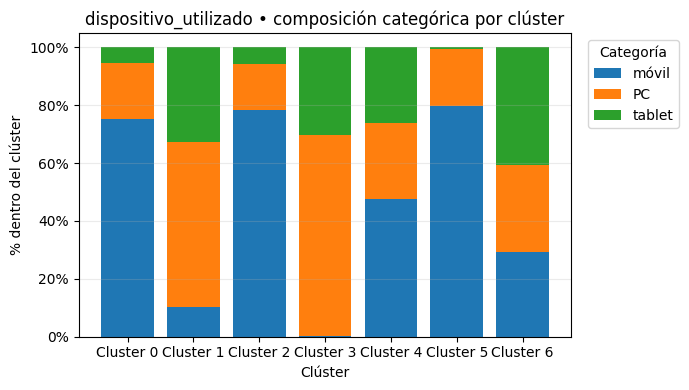

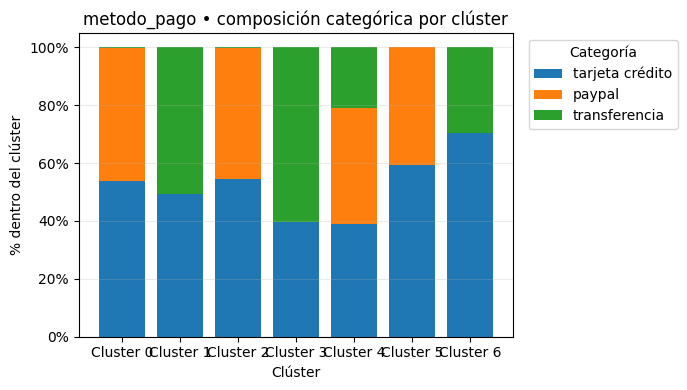

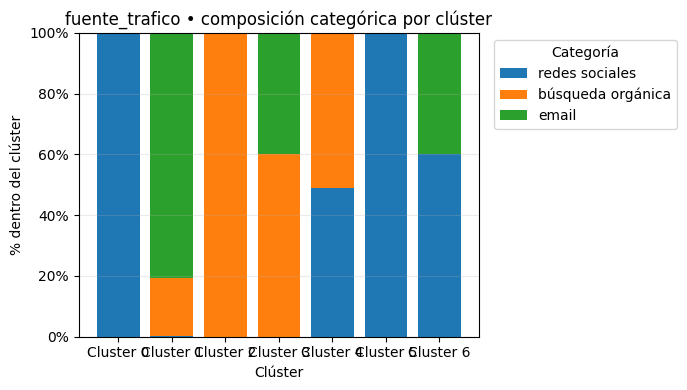

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

cluster_dfs = [
    cluster_0_df, cluster_1_df, cluster_2_df,
    cluster_3_df, cluster_4_df, cluster_5_df, cluster_6_df
]
cluster_labels = list(range(len(cluster_dfs)))

common_cols = set(cluster_dfs[0].columns)
for cdf in cluster_dfs[1:]:
    common_cols &= set(cdf.columns)
common_cols = list(common_cols)

sample_df = pd.concat([cdf[common_cols].head(200) for cdf in cluster_dfs], axis=0, ignore_index=True)
num_cols_auto = sample_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_auto = [c for c in common_cols if c not in num_cols_auto]
num_cols = num_cols_auto
cat_cols = cat_cols_auto

def violin_by_cluster(cluster_dfs, col, labels, figsize=(7,4)):
    data = [cdf[col].dropna().values for cdf in cluster_dfs if col in cdf.columns]
    if len(data) != len(cluster_dfs) or all(len(d)==0 for d in data):
        return
    fig, ax = plt.subplots(figsize=figsize)
    ax.violinplot(data, showmedians=False, showextrema=False)
    meds = [np.median(d) if len(d)>0 else np.nan for d in data]
    ax.plot(range(1, len(data)+1), meds, marker='o', linestyle='-', linewidth=2)
    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels([f"Cluster {k}" for k in labels])
    ax.set_title(f"{col} • distribución por clúster")
    ax.set_xlabel("Clúster")
    ax.set_ylabel(col)
    ax.grid(alpha=0.25)
    plt.show()

def stacked_percent_bar(cluster_dfs, col, labels, top_n=8, figsize=(7,4)):
    counts_per_cluster = []
    for cdf in cluster_dfs:
        if col not in cdf.columns:
            return
        vc = cdf[col].astype("category").value_counts(dropna=False)
        counts_per_cluster.append(vc)
    all_counts = pd.concat(counts_per_cluster, axis=1).fillna(0).sum(1).sort_values(ascending=False)
    cats = all_counts.index.astype(str).tolist()
    if len(cats) > top_n:
        top_cats = list(map(str, all_counts.index[:top_n]))
    else:
        top_cats = list(map(str, all_counts.index))
    rows = []
    for k, cdf in zip(labels, cluster_dfs):
        s = cdf[col].astype(str).fillna("NaN").copy()
        share = s.value_counts(normalize=True)
        row = {cat: share.get(cat, 0.0) for cat in top_cats}
        if len(cats) > top_n:
            row["Otros"] = 1.0 - sum(row.values())
        rows.append(pd.Series(row, name=f"Cluster {k}"))
    pct = pd.DataFrame(rows).fillna(0.0)
    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(pct))
    for cat in pct.columns:
        ax.bar(pct.index, pct[cat].values, bottom=bottom, label=cat)
        bottom += pct[cat].values
    ax.set_title(f"{col} • composición categórica por clúster")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylabel("% dentro del clúster")
    ax.set_xlabel("Clúster")
    ax.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

for col in num_cols:
    violin_by_cluster(cluster_dfs, col, cluster_labels, figsize=(7,4))

for col in cat_cols:
    stacked_percent_bar(cluster_dfs, col, cluster_labels, top_n=8, figsize=(7,4))



# Graficos
Al observar este metodo de graficos, es mucho más claro el la diferenciación de cada cluster.

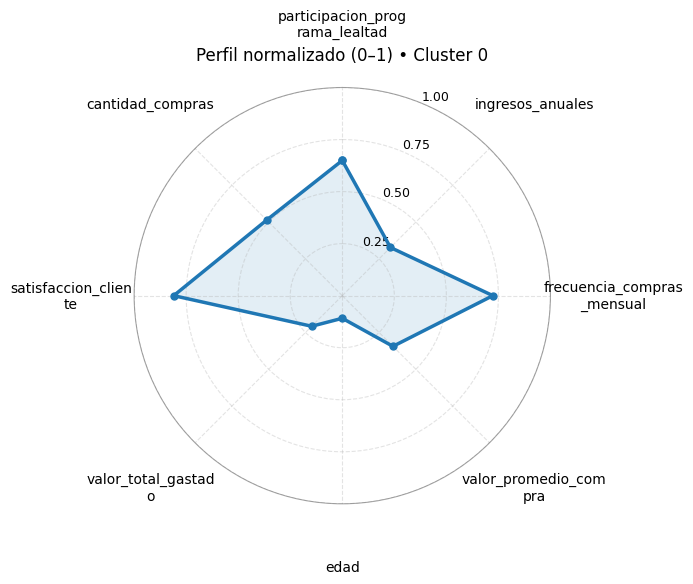

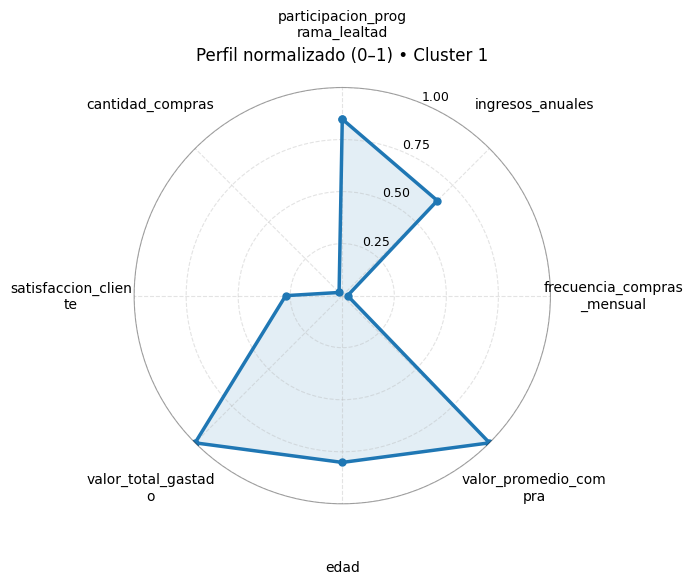

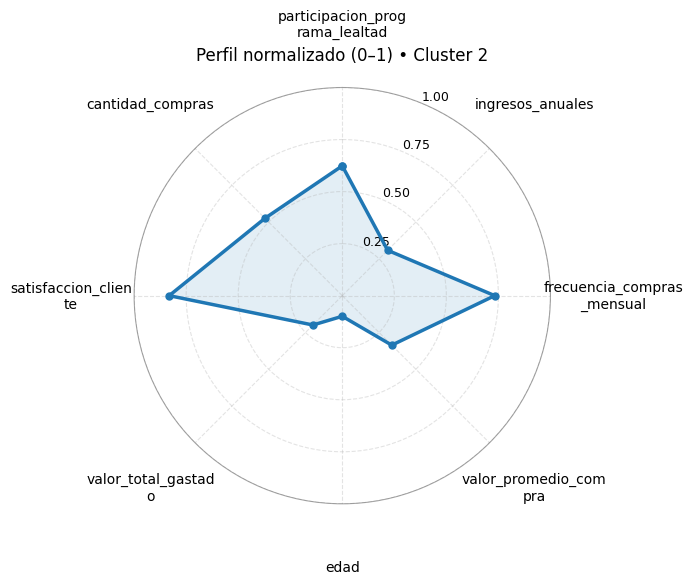

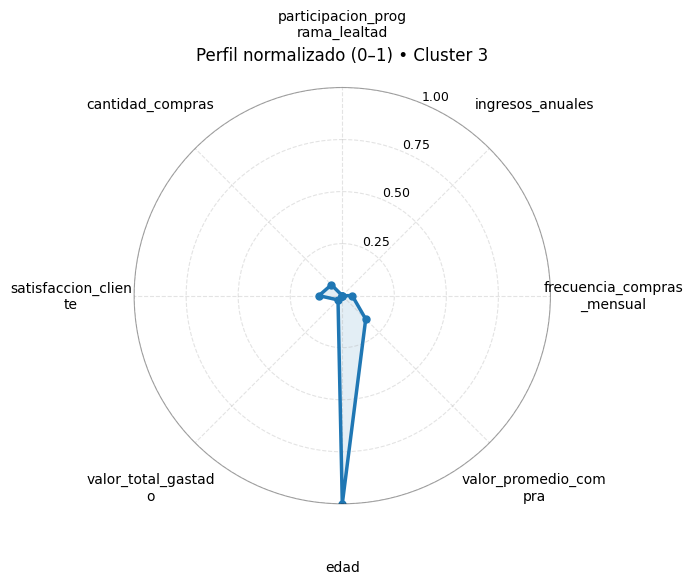

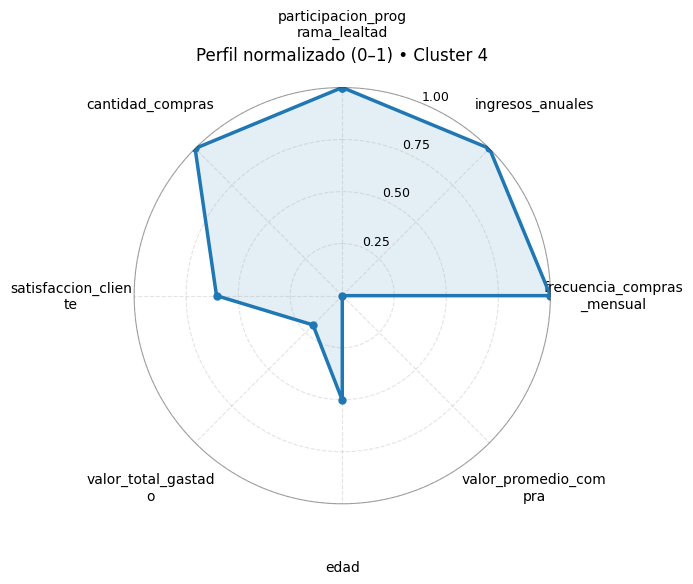

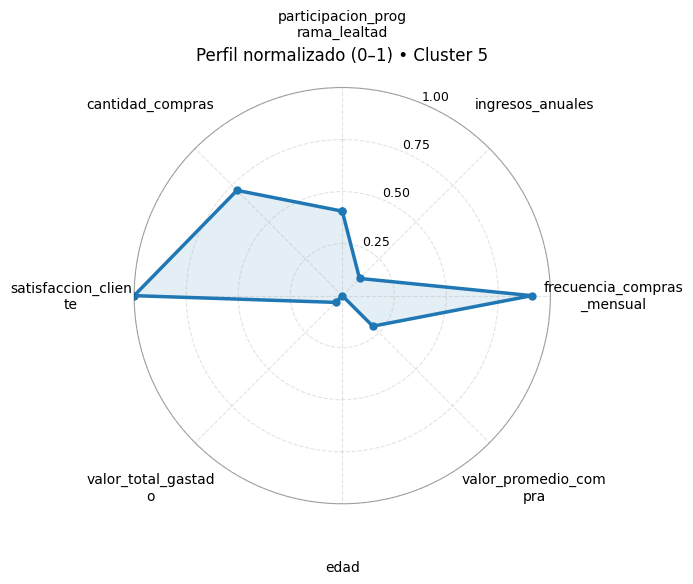

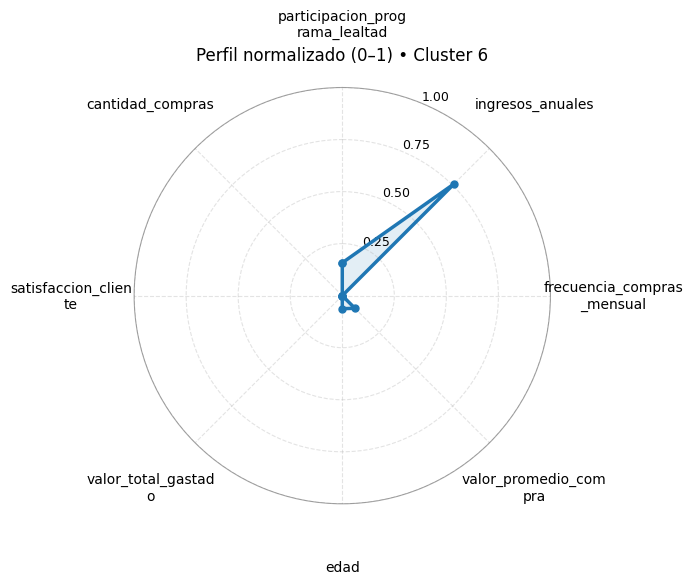

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

def _wrap_labels(labels, width=16):
    return ['\n'.join(textwrap.wrap(str(x), width=width)) for x in labels]

def cluster_radar_per_cluster_spaced(cluster_dfs, labels, cols, title_prefix="Perfil •", label_wrap=16, pad=25):
    if not cols:
        return
    num_cols_in_each = []
    for cdf in cluster_dfs:
        num_cols_in_each.append([c for c in cols if c in cdf.columns and pd.api.types.is_numeric_dtype(cdf[c])])
    common_num_cols = set(num_cols_in_each[0])
    for lst in num_cols_in_each[1:]:
        common_num_cols &= set(lst)
    cols = list(common_num_cols)
    if len(cols) == 0:
        return

    means = np.array([cdf[cols].mean(numeric_only=True).values for cdf in cluster_dfs])
    df_means = pd.DataFrame(means, index=[f"Cluster {k}" for k in labels], columns=cols)

    q_low = df_means.quantile(0.05)
    q_hi  = df_means.quantile(0.95)
    df_clipped = df_means.clip(lower=q_low, upper=q_hi, axis=1)
    df_scaled = (df_clipped - q_low) / (q_hi - q_low + 1e-9)
    categories = _wrap_labels(cols, width=label_wrap)

    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    for i, idx in enumerate(df_scaled.index):
        values = df_scaled.iloc[i].tolist()
        values += values[:1]

        fig = plt.figure(figsize=(7,7))
        ax = plt.subplot(111, polar=True)

        ax.set_theta_offset(np.pi/2)
        ax.set_theta_direction(-1)
        ax.set_ylim(0, 1)

        ax.plot(angles, values, linewidth=2.5, marker='o', markersize=5)
        ax.fill(angles, values, alpha=0.12)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=10)
        ax.tick_params(pad=pad)  # <<< aquí controlas la separación

        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["0.25","0.50","0.75","1.00"], fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.35)
        ax.spines['polar'].set_alpha(0.35)

        ax.set_title(f"{title_prefix} {idx}", pad=20)
        plt.tight_layout()
        plt.show()

vars_radar = num_cols[:8]
cluster_radar_per_cluster_spaced(cluster_dfs, cluster_labels, vars_radar, title_prefix="Perfil normalizado (0–1) •", label_wrap=18, pad=35)


# Radar (perfil normalizado):
 resume varias medias de variables clave en una sola “huella”. Vemos el perfil de cada cluster entre los numericos, se observa mejor el perfil.
 Cabe recalcar: que esta el titulo, arriba esta la edad. Eso hace parte de donde esta el titulo ubicado debajo, es un error del codigo.

 Este grafico necesita, de apoyo de los de arriba, para complementar el perfil.

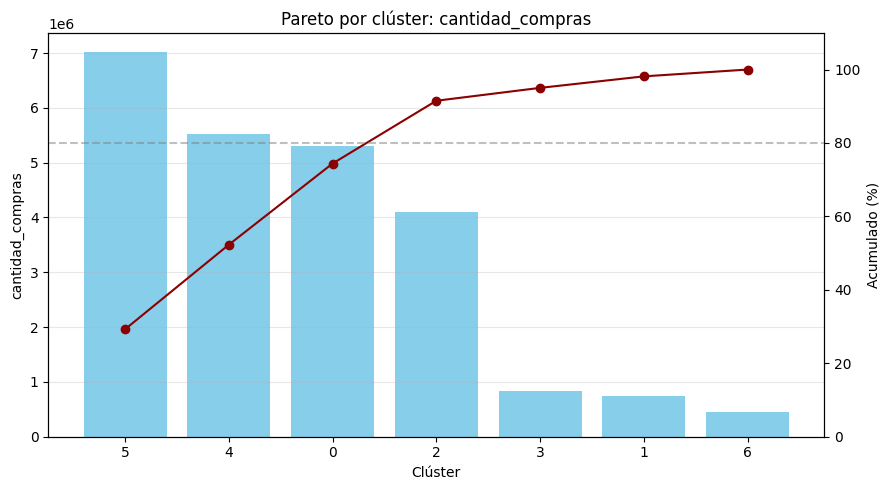

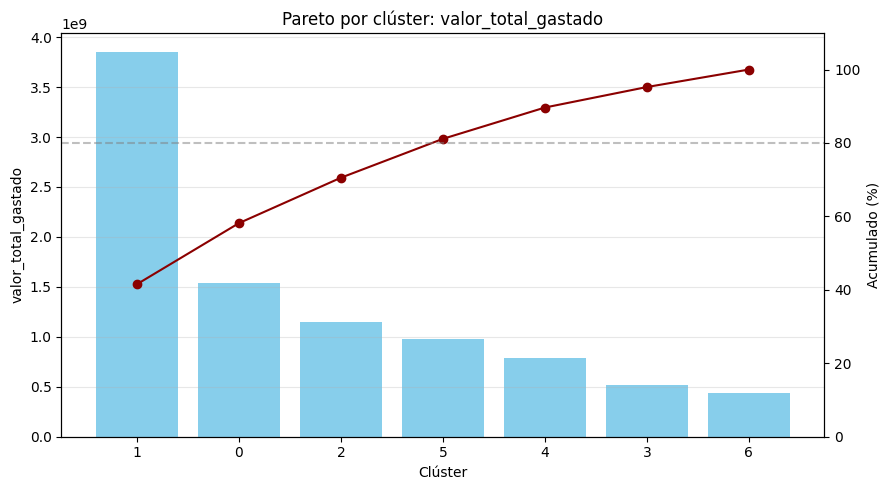

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def pareto_cluster_metric(cluster_dfs, labels, metric_col, agg="sum", title_prefix="Pareto"):
    valores = []
    for cdf in cluster_dfs:
        if metric_col in cdf.columns:
            if agg == "sum":
                valores.append(cdf[metric_col].sum())
            elif agg == "mean":
                valores.append(cdf[metric_col].mean())
            else:
                valores.append(len(cdf))
        else:
            valores.append(0)
    df = pd.DataFrame({"cluster": labels, "valor": valores})
    df = df.sort_values("valor", ascending=False).reset_index(drop=True)
    df["pct"] = df["valor"] / df["valor"].sum()
    df["acum"] = df["pct"].cumsum()

    fig, ax1 = plt.subplots(figsize=(9,5))
    ax1.bar(df["cluster"].astype(str), df["valor"], color="skyblue")
    ax1.set_xlabel("Clúster")
    ax1.set_ylabel(metric_col)
    ax1.grid(axis="y", alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(df["cluster"].astype(str), df["acum"]*100, marker="o", color="darkred")
    ax2.set_ylabel("Acumulado (%)")
    ax2.set_ylim(0, 110)
    ax2.axhline(80, linestyle="--", color="gray", alpha=0.5)

    plt.title(f"{title_prefix}: {metric_col}")
    plt.tight_layout()
    plt.show()

    return df[["cluster","valor","pct","acum"]]

# Pareto por cantidad de compras
pareto_cantidad = pareto_cluster_metric(cluster_dfs, cluster_labels, "cantidad_compras", agg="sum", title_prefix="Pareto por clúster")

# Pareto por ventas totales
pareto_ventas = pareto_cluster_metric(cluster_dfs, cluster_labels, "valor_total_gastado", agg="sum", title_prefix="Pareto por clúster")



# Perfil de Clusters:

En el **Cluster 0** se encuentran clientes jóvenes, de entre 20 y 40 años, con una edad promedio de 30. Su cantidad de compras no es demasiado alta, pero sí constante, superando las 20 transacciones. Sus ingresos anuales no son elevados, lo que refleja un perfil de adulto joven universitario, independiente o recién mudado. El valor promedio de compra está entre 200 y 600, con una media de 400, lo que confirma que no realizan adquisiciones costosas. Compran entre 6 y 12 veces al mes, lo que sugiere que están equipando su hogar, y los días desde la última compra no superan los 50. Son clientes satisfechos (promedio de 4.0), aunque su gasto total no es alto, ya que tienden a ahorrar. Participan en el programa de lealtad y suelen adquirir celulares o computadoras. Su perfil es de universitarios o recién graduados que utilizan intensamente el móvil y el PC. Llegan a la tienda a través de redes sociales, lo que los asocia a la generación Z confiada en el comercio electrónico. Pagan con tarjeta de crédito y PayPal, y suelen premeditar la compra: primero buscan en redes y luego adquieren lo que ya tenían en mente.

El **Cluster 1** está compuesto por clientes de entre 40 y 70 años, con una media de 55. Su nivel de compras es bajo, inestable y poco constante. Tienen ingresos anuales superiores al promedio, aunque no excesivos. Se trata de cabezas de hogar o abuelos que realizan inversiones puntuales una vez al año para reemplazar productos dañados. No son compradores compulsivos. Su frecuencia de compra es mínima (0 a 1), y el tiempo desde la última adquisición varía entre 50 y 365 días, con un promedio de 200. Su nivel de satisfacción es intermedio, con 3.2 en promedio, lo que sugiere que compran más por necesidad que por gusto. Prefieren productos como electrodomésticos, computadores y accesorios, pero no muestran interés en móviles. Su comportamiento coincide con personas mayores o responsables del hogar. Utilizan PC, tablet y móvil para explorar la tienda, aunque predominan los usuarios de PC, que solo compran al recibir un correo electrónico. Pagan principalmente con transferencia y tarjeta de crédito. Cuando compran, suelen hacer inversiones altas en un solo producto. Participan en el programa de lealtad, aunque compran muy poco, casi solo una vez al año.

El **Cluster 2** comparte características etarias con el Cluster 0, con edades de entre 20 y 40 años y un promedio de 30. Su cantidad de compras también es moderada pero constante, con más de 20 adquisiciones. Sus ingresos son bajos, lo que perfila a jóvenes universitarios, independientes o recién mudados. El valor promedio de compra está entre 200 y 600, con media de 400. Compran entre 6 y 12 veces al mes, y el tiempo desde la última compra no supera los 50 días. Su nivel de satisfacción es alto (4.0), aunque el gasto total no es elevado. Participan en el programa de lealtad y diversifican sus compras: adquieren accesorios, móviles, computadoras y electrodomésticos. Llegan por búsqueda orgánica y muestran un comportamiento más impulsivo, comprando lo que ven al pasar por la tienda. Usan principalmente el móvil, en menor medida el PC o la tablet. Son compradores jóvenes, más guiados por lo que descubren en el momento que por lo que investigan en redes. Pagan con PayPal y tarjeta de crédito.

En el **Cluster 3** predominan adultos mayores de entre 60 y 70 años, con ingresos muy bajos. Su nivel de compras es mínimo, de 0 a 8, y el valor promedio apenas llega a 250. No participan en el programa de lealtad y suelen comprar de manera muy poco frecuente. El tiempo desde la última compra oscila entre 50 y 200 días. Su nivel de satisfacción es bajo, con un promedio de 3.0, lo que refleja insatisfacción con el servicio o los productos. Compran accesorios, electrodomésticos y computadores, principalmente por PC o tablet, utilizando la búsqueda orgánica y, en menor medida, el correo electrónico. Pagan con transferencia y tarjeta de crédito. Se trata de un perfil difícil de fidelizar: adultos mayores con bajos ingresos que prefieren la tienda física y que suelen quedar inconformes con las compras en línea.

El **Cluster 4** agrupa clientes de entre 40 y 55 años, con un promedio de 45. Es el grupo con mayor cantidad de compras, de entre 20 y 48, con un promedio de 35. También es el clúster con mayores ingresos. Curiosamente, su valor promedio de compra es bajo, entre 100 y 200, con una media de 150. Destacan por ser los más frecuentes, con alrededor de 11 compras al mes. Participan activamente en el programa de lealtad y tienden a estar satisfechos, con promedios superiores a 3.8. Sus compras incluyen accesorios, móviles y electrodomésticos, y utilizan sobre todo el móvil, aunque también PC y tablet. Llegan en igual medida por redes sociales y búsqueda orgánica, y pagan con tarjeta de crédito, PayPal o transferencia. Este perfil puede corresponder a personas recién mudadas o con hijos, que compran con frecuencia pero sin gastar demasiado por transacción.

El **Cluster 5** está conformado por jóvenes de entre 20 y 35 años, con una edad promedio de 28. Realizan unas 25 compras, más que la mayoría de los clústeres, aunque menos que el 4. Sus ingresos anuales son muy bajos, los segundos más bajos después del Cluster 3. El valor promedio de compra oscila entre 100 y 600, con una media de 300. Su frecuencia es alta, con compras cada pocos días, aunque no son leales al programa, lo que plantea la duda de si requieren mayores incentivos para unirse. Su nivel de satisfacción es el más alto de todos los clústeres. Compran principalmente accesorios y algunos electrodomésticos. Existe la posibilidad de que se trate de compradores revendedores. Utilizan casi exclusivamente el móvil, algo el PC y muy poco la tablet. Llegan por redes sociales y pagan con tarjeta de crédito o PayPal.

Finalmente, el **Cluster 6** agrupa a personas de entre 25 y 35 años, con un promedio de 30. Tienen ingresos relativamente altos, segundos después del Cluster 4, pero su cantidad de compras es mínima: entre 0 y 6, con un promedio de 4. El valor promedio de compra es bajo (200), y su frecuencia mensual es la más reducida, apenas 1 compra. No participan en el programa de lealtad y su gasto total es poco significativo. Los días desde la última compra oscilan entre 200 y 365, con un promedio de 225. Su satisfacción es la más baja de todos los grupos, con un promedio de 2.7, lo que sugiere experiencias negativas con el servicio o producto. Compran accesorios, móviles y computadores, utilizando móvil, PC y tablet, pero no acuden a la tienda física. Prefieren email o redes sociales, lo que puede explicar su baja satisfacción al no poder ver el producto antes de adquirirlo. Pagan con tarjeta de crédito.

# Analizar El Pareto

El Pareto por cantidad de compras muestra que la mayor parte de las transacciones se concentra en pocos clústeres. Los clústeres 5, 4 y 0 acumulan juntos más del 80% del total de compras. Esto indica que el grueso del movimiento en la tienda proviene de clientes jóvenes o de mediana edad que mantienen un hábito de compra constante. Sin embargo, aunque estos clústeres realizan muchas transacciones, no necesariamente generan los mayores ingresos por ticket de compra. Los demás clústeres, como el 2, 3, 1 y 6, aportan un volumen reducido y marginal en cuanto a número de compras, lo que los hace menos relevantes en términos de recurrencia.

Cuando se analiza el Pareto por valor total gastado, la situación cambia. El clúster 1 sobresale con claridad, concentrando cerca del 40% de los ingresos totales, pese a que no es uno de los grupos más frecuentes en compras. Le siguen los clústeres 0 y 2, que junto con el 1 alcanzan rápidamente más del 80% del total facturado. En contraste, el clúster 5, que lideraba en número de transacciones, pierde relevancia en valor económico, confirmando que se trata de clientes que compran con frecuencia pero con montos bajos. Los clústeres 4, 3 y 6 tienen una participación menor en términos de ingresos, ubicándose en la parte baja de la contribución económica.

En conjunto, los resultados evidencian una diferencia clara entre frecuencia y rentabilidad. Mientras que los clústeres jóvenes sostienen el mayor volumen de compras, son los clústeres menos frecuentes los que concentran el mayor gasto, en especial el clúster 1. Esto sugiere la necesidad de estrategias diferenciadas: por un lado, fidelizar y aumentar el valor del ticket promedio en los clientes jóvenes y activos; y por otro, priorizar la retención y el tratamiento personalizado de aquellos clientes que, aunque compran con menor frecuencia, representan la mayor fuente de ingresos.


# Ideas de Negocio
El modelo de segmentación y el análisis Pareto muestran un gran potencial para transformar la gestión comercial y de marketing en la empresa. Más allá de identificar grupos de clientes con características similares, este enfoque permite diseñar estrategias altamente personalizadas, optimizando recursos y maximizando tanto la satisfacción del cliente como la rentabilidad del negocio.

Por ejemplo, los clientes que compran una vez al año a través de correo electrónico podrían recibir campañas específicas con descuentos estacionales, recordatorios personalizados o incentivos ligados a aniversarios de compra. De esta manera, se logra mantener el contacto y se incentiva la recurrencia en un canal que ellos ya prefieren.
En el caso de los clientes jóvenes con alta frecuencia de compra pero bajos ingresos, que aún no son leales, podrían diseñarse programas de fidelización de bajo costo de entrada, como membresías gratuitas con beneficios acumulables, sistemas de puntos o cupones inmediatos. Esto les permitiría seguir comprando de manera frecuente y, al mismo tiempo, percibir un valor agregado que fomente su permanencia.

Los clientes insatisfechos que compran a través de redes sociales podrían ser atendidos con estrategias de confianza, como devoluciones gratuitas, cambios sin costo o la posibilidad de consultar reseñas verificadas antes de comprar. También sería valioso implementar un sistema de encuestas rápidas poscompra para detectar inconformidades y corregirlas antes de que se conviertan en abandono definitivo.

Para los clústeres que generan altos ingresos en pocas transacciones, el reto está en ofrecer exclusividad. Se podrían diseñar programas VIP, invitaciones a preventas o acceso prioritario a productos de alta gama, reforzando la percepción de valor premium y asegurando que estos clientes mantengan su nivel de gasto.

Por otro lado, para los clientes que gastan poco pero compran con frecuencia, podrían aplicarse estrategias de “cross-selling” y “up-selling”. Al analizar sus patrones de consumo, se les podrían recomendar productos complementarios o paquetes con descuentos que eleven su ticket promedio, manteniendo su ritmo de compras sin que perciban un gasto excesivo.

Finalmente, los clústeres de bajo compromiso, como aquellos que no participan en programas de lealtad o que tienen baja satisfacción, representan una oportunidad para reestructurar la experiencia. La empresa podría implementar pruebas piloto con beneficios adicionales, como envíos gratuitos al superar cierto monto, recomendaciones personalizadas según historial de compra o incluso gamificación del proceso de compra (recompensas por hitos alcanzados).

En suma, el modelo no solo clasifica, sino que se convierte en una brújula estratégica. Su aplicación empresarial abre la posibilidad de alinear acciones de marketing, fidelización y servicio al cliente de forma segmentada y eficiente. Al adaptar la experiencia de compra a las particularidades de cada clúster, la empresa no solo optimiza ingresos, sino que también fortalece vínculos duraderos con distintos tipos de consumidores.

#Cierre


El análisis de segmentación reveló que los clientes presentan patrones de consumo claramente diferenciados. Algunos clústeres, como los 5, 4 y 0, concentran la mayor parte de las transacciones, lo que refleja un perfil joven, activo y frecuente, aunque con montos de compra bajos. En contraste, el clúster 1, a pesar de comprar con poca frecuencia, representa la mayor proporción de ingresos gracias a un ticket promedio más elevado. Este hallazgo confirma que la frecuencia de compra no está directamente ligada al valor económico y que existen distintos tipos de clientes que sostienen al negocio: unos aportan volumen y otros rentabilidad.

La relevancia de estos resultados radica en la posibilidad de aplicar estrategias empresariales diferenciadas. Los clientes frecuentes pero de bajo gasto pueden ser incentivados con programas de fidelización, promociones de ventas cruzadas y descuentos para aumentar su ticket promedio. Los clientes de alto valor, aunque menos constantes, requieren un trato prioritario, con beneficios exclusivos y atención personalizada para asegurar su retención. Por otro lado, los segmentos con baja satisfacción reflejan áreas críticas de mejora en el servicio y la experiencia de compra, donde la implementación de políticas de devolución gratuita o incentivos de confianza puede ser decisiva.

El proceso de segmentación y el análisis Pareto demostraron ser herramientas esenciales para transformar datos en conocimiento estratégico. No solo permitieron describir el presente, sino también anticipar comportamientos futuros y diseñar acciones preventivas. Identificar clientes en riesgo, descubrir oportunidades de crecimiento en segmentos jóvenes y priorizar recursos en los más rentables constituye una ventaja competitiva clave. En este sentido, la segmentación y la predicción no deben entenderse como un ejercicio puramente técnico, sino como un pilar para la toma de decisiones empresariales, ya que facilitan la personalización, aumentan la fidelidad y orientan a un crecimiento sostenible en mercados cada vez más competitivos.